In [235]:
# ============================================================
# N4 — EXPLORE & AGGREGATE - Fact News Territoires
# ============================================================
# This notebook performs:
# 1. Exploratory Data Analysis (EDA) on each dataset
# 2. Aggregation at commune level
# 3. Preparation of a unified analytical table for N5

In [236]:
#=====================================================
# Install libraries
#=====================================================

In [237]:
#!pip install pandas requests duckdb openpyxl matplotlib seaborn numpy dotenv

In [238]:
#=====================================================
# Import libraries
#=====================================================

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
#to draw graphs directly in notebook

In [240]:
# =========================================================================
# I — Exploratory Data Analysis (EDA)
# =========================================================================
# This section explores datasets prepared in N3 one by one in order to:
# - assess data quality
# - understand variable distributions
# - identify potential biases and outliers

In [241]:
# ========================================================================
# A — Load datasets for exploration
# ========================================================================
# All cleaned CSV files are loaded into DataFrames for exploratory analysis and validation.

In [242]:
insee_to_commune_subset = pd.read_csv(
    "cleaned_data_complete_subset/insee_to_commune_complete.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
insee_to_commune_subset["insee_commune_id"] = (
    insee_to_commune_subset["insee_commune_id"]
    .str.zfill(5)
)
insee_to_commune_subset.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,592.0
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,4.0,39.0,95.0,328.0,59.0,525.0
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,4.0,41.0,46.0,258.0,56.0,405.0
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,5.0,96.0,104.0,1517.0,304.0,2026.0
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,3.0,8.0,9.0,195.0,33.0,248.0


In [243]:
disposable_income_subset = pd.read_csv(
    "cleaned_data_complete_subset/disposable_income_2021_complete.csv", 
    sep=",",
    dtype={
        "insee_commune_id": str,
        "iris_id": str}
)
disposable_income_subset["insee_commune_id"] = (
    disposable_income__subset["insee_commune_id"]
    .str.zfill(5)
)
disposable_income_subset["iris_id"] = (
    disposable_income__subset["iris_id"]
    .str.zfill(9)
)
disposable_income_subset.head()

,insee_commune_id,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,010040101,Ambérieu-en-Bugey,Les Pérouses-Triangle d'Activités,19.0,14990.0,20350.0,26140.0,11620.0,32060.0,70.8,26.9,6.2,8.6,3.3,3.8,1.5,-12.5
1,01004,010040102,Ambérieu-en-Bugey,Longeray-Gare,25.0,13880.0,18570.0,24760.0,10580.0,31130.0,70.6,24.9,5.8,11.1,3.7,5.1,2.3,-12.4
2,01004,010040201,Ambérieu-en-Bugey,Centre-Saint-Germain-Vareilles,19.0,15190.0,20700.0,27180.0,11400.0,34450.0,72.5,27.2,6.4,7.7,2.8,3.3,1.6,-13.8
3,01004,010040202,Ambérieu-en-Bugey,Tiret-Les Allymes,8.0,19600.0,25230.0,33170.0,14810.0,41230.0,73.3,23.8,16.2,4.0,1.8,1.5,0.7,-17.3
4,01033,010330102,Valserhône,Centre Ville,24.0,14050.0,20420.0,29640.0,9410.0,42390.0,78.9,23.7,5.2,5.3,1.5,2.5,1.3,-13.1


In [244]:
disposable_income_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   insee_commune_id                 2457 non-null   str    
 1   iris_id                          2457 non-null   str    
 2   commune_name                     2457 non-null   str    
 3   place_in_commune                 2457 non-null   str    
 4   taux_bas_revenus_pct             2457 non-null   float64
 5   revenu_q1_eur                    2457 non-null   float64
 6   revenu_median_eur                2457 non-null   float64
 7   revenu_q3_eur                    2457 non-null   float64
 8   revenu_d1_eur                    2457 non-null   float64
 9   revenu_d9_eur                    2457 non-null   float64
 10  part_revenus_activite_pct        2457 non-null   float64
 11  part_pensions_pct                2457 non-null   float64
 12  part_revenus_patrimoine_pct    

In [245]:
crime_subset = pd.read_csv(
    "cleaned_data_complete_subset/crime_complete.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
crime_subset["insee_commune_id"] = (
    crime_subset["insee_commune_id"]
    .str.zfill(5)
)
crime_subset.head()

,insee_commune_id,annee,crime_type,unite_de_compte,nombre,taux_pour_mille,insee_pop_ref,data_available
0,01004,2016,Violences physiques intrafamiliales,Victime,28.0,1.988495,14081,True
1,01004,2016,Violences physiques hors cadre familial,Victime,53.0,3.763937,14081,True
2,01004,2016,Violences sexuelles,Victime,13.0,0.923230,14081,True
3,01004,2016,Vols avec armes,Infraction,NaN,NaN,14081,False
4,01004,2016,Vols violents sans arme,Infraction,NaN,NaN,14081,False


In [246]:
air_pollution_subset = pd.read_csv(
    "cleaned_data_complete_subset/air_pollution_complete.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
air_pollution_subset["insee_commune_id"] = (
    air_pollution_subset["insee_commune_id"]
    .str.zfill(5)
)
air_pollution_subset.head()

,insee_commune_id,commune_name,agglomeration_zone,measure_date,year,quarter,no2_level,o3_level,pm10_level,pm25_level,so2_level,air_quality_label,data_source,x_lambert93,longitude,y_lambert93,latitude
0,01004,Ambérieu-en-Bugey,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,882724.8,5.359568,6542583.8,45.958394
1,01033,Bellegarde-sur-Valserine,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,918253.7,5.826201,6560331.1,46.107618
2,01173,Gex,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,935186.0,6.058178,6586121.2,46.334012
3,01283,Oyonnax,Lyon,2025-01-01,2025,1,1.0,2.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,904524.8,5.655610,6576521.2,46.257610
4,03023,Bellerive-sur-Allier,Lyon,2025-01-01,2025,1,1.0,1.0,1.0,2.0,1.0,Moyen,Atmo Auvergne-Rhône-Alpes,730986.8,3.401239,6557568.1,46.117204


In [247]:
# ============================================================
# B — Exploratory Data Analysis (EDA)
# ============================================================
# This section explores each dataset individually before aggregation.
#
# The objective is to:
# - assess data quality and completeness
# - understand variable distributions
# - detect potential outliers or inconsistencies
# - identify structural patterns within each dataset
#
# This step is essential to guide aggregation choices in the next phase (commune-level analysis).

In [248]:
# ============================================================
# B.1 — insee_to_commune dataset
# ============================================================

In [249]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [250]:
insee_to_commune_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   insee_commune_id           362 non-null    str    
 1   commune_name               362 non-null    str    
 2   population_total           362 non-null    float64
 3   density_class              362 non-null    float64
 4   density_label              362 non-null    str    
 5   count_agriculture          362 non-null    float64
 6   count_industry             362 non-null    float64
 7   count_construction         362 non-null    float64
 8   count_commercial_services  362 non-null    float64
 9   count_public_services      362 non-null    float64
 10  total_count                362 non-null    float64
dtypes: float64(8), str(3)
memory usage: 31.2 KB


In [251]:
insee_to_commune_subset.isna().sum()

insee_commune_id             0
commune_name                 0
population_total             0
density_class                0
density_label                0
count_agriculture            0
count_industry               0
count_construction           0
count_commercial_services    0
count_public_services        0
total_count                  0
dtype: int64

In [252]:
# OBSERVATION: 
# dtypes : OK
# NaN : None

In [253]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [254]:
insee_to_commune_subset.describe()

,population_total,density_class,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count
count,362.00000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000
mean,19770.88674,1.828729,9.765193,49.425414,85.930939,553.806630,89.157459,788.085635
std,29981.51234,0.565346,18.123999,56.205511,129.492524,958.164309,152.229452,1283.554975
min,3649.00000,1.000000,0.000000,1.000000,1.000000,54.000000,13.000000,88.000000
25%,7841.75000,2.000000,1.000000,20.000000,32.000000,174.250000,28.000000,272.500000
50%,10721.00000,2.000000,4.000000,33.000000,52.000000,280.500000,43.500000,421.000000
75%,19197.00000,2.000000,9.750000,57.750000,92.000000,588.750000,85.750000,830.500000
max,360710.00000,4.000000,202.000000,537.000000,1850.000000,12087.000000,1826.000000,16327.000000


In [255]:
# OBSERVATION: 

# General remark:
# This subset includes 362 communes out of an initial 34,876 (~1% of total), and is restricted to areas with complete data coverage.
# Results should therefore not be generalized to the entire territory.

# Density class: 
# value 1 = Urbain dense, value 2 = Urbain intermédiaire, value 3 = Rural périurbain, value 4 = Rural non périurbain
# The distribution is concentrated around value 2, with a mean slightly below 2, indicating that the majority of communes in the dataset are classified as urban intermediate.
# Highly dense or rural communes are less represented in this subset.

# Economic activity:
# The number of establishments shows strong heterogeneity across communes.
# Large gaps between minimum and maximum values across all categories highlight significant differences in local economic structures.

# Dispersion:
# Standard deviations are high relative to the means, indicating a strong variability and the presence of highly active communes driving the upper range of the distribution.

# Analytical implication:
# Absolute counts are not directly comparable between communes of different sizes ==> Normalization (e.g. per 1,000 inhabitants) would improve comparability across territories.

In [256]:
# ADDITIONAL INVESTIGATION:

# It would be valuable to compare the distribution of key variables between the restricted subset (362 communes with complete data)
# and the full dataset of communes in France (cleaned_data/insee_to_commune_clean).

# This comparison would allow assessment of the representativeness of the subset, and help identify potential selection bias (e.g. overrepresentation of urban areas).

In [257]:
# first load insee_to_commune global dataset
insee_to_commune_global = pd.read_csv(
    "cleaned_data/insee_to_commune_clean.csv",
    sep=",",
    dtype={"insee_commune_id": str}
)
insee_to_commune_global["insee_commune_id"] = (
    insee_to_commune_global["insee_commune_id"]
    .str.zfill(5)
)
insee_to_commune_global.head()

,insee_commune_id,commune_name_upper,commune_name,has_crime_data,has_income_data_any,has_income_data_all,income_data_coverage,has_air_pollution_data,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count,economy_data_status,available_source_count,data_coverage_status
0,01001,ABERGEMENT CLEMENCIAT,Abergement-Clémenciat,False,False,False,0.0,True,876.0,4.0,Rural non périurbain,4.0,0.0,3.0,10.0,2.0,19.0,complete,1,partial_data
1,01002,ABERGEMENT DE VAREY,Abergement-de-Varey,False,False,False,0.0,True,276.0,4.0,Rural non périurbain,1.0,0.0,0.0,2.0,1.0,4.0,complete,1,partial_data
2,01004,AMBERIEU EN BUGEY,Ambérieu-en-Bugey,True,True,True,1.0,True,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,592.0,complete,3,fully_complete
3,01005,AMBERIEUX EN DOMBES,Ambérieux-en-Dombes,True,False,False,0.0,True,1930.0,3.0,Rural périurbain,2.0,4.0,10.0,25.0,8.0,49.0,complete,2,partial_data
4,01006,AMBLEON,Ambléon,False,False,False,0.0,True,115.0,4.0,Rural non périurbain,0.0,0.0,0.0,0.0,1.0,1.0,complete,1,partial_data


In [258]:
#just keep needed info
cols_to_drop = [
    "commune_name_upper",
    "has_crime_data",
    "has_income_data_any",
    "has_income_data_all",
    "has_air_pollution_data", 
    "economy_data_status", 
    "available_source_count", 
    "data_coverage_status",
    "income_data_coverage"
]

insee_to_commune_global.drop(
    columns=cols_to_drop,
    inplace=True
)

insee_to_commune_global.reset_index(drop=True, inplace=True)

insee_to_commune_global.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count
0,01001,Abergement-Clémenciat,876.0,4.0,Rural non périurbain,4.0,0.0,3.0,10.0,2.0,19.0
1,01002,Abergement-de-Varey,276.0,4.0,Rural non périurbain,1.0,0.0,0.0,2.0,1.0,4.0
2,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,592.0
3,01005,Ambérieux-en-Dombes,1930.0,3.0,Rural périurbain,2.0,4.0,10.0,25.0,8.0,49.0
4,01006,Ambléon,115.0,4.0,Rural non périurbain,0.0,0.0,0.0,0.0,1.0,1.0


In [259]:
insee_to_commune_global.info()

<class 'pandas.DataFrame'>
RangeIndex: 34876 entries, 0 to 34875
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   insee_commune_id           34876 non-null  str    
 1   commune_name               34876 non-null  str    
 2   population_total           34855 non-null  float64
 3   density_class              34875 non-null  float64
 4   density_label              34875 non-null  str    
 5   count_agriculture          34511 non-null  float64
 6   count_industry             34511 non-null  float64
 7   count_construction         34511 non-null  float64
 8   count_commercial_services  34511 non-null  float64
 9   count_public_services      34511 non-null  float64
 10  total_count                34511 non-null  float64
dtypes: float64(8), str(3)
memory usage: 2.9 MB


In [260]:
insee_to_commune_global.describe()

,population_total,density_class,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count
count,34855.000000,34875.000000,34511.000000,34511.000000,34511.000000,34511.000000,34511.000000,34511.000000
mean,1886.586946,3.320258,3.365536,4.370693,7.547594,45.259743,8.794906,69.338472
std,8308.478145,0.737069,5.934589,31.417139,57.712309,919.650556,83.849678,1084.874963
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,202.000000,3.000000,1.000000,0.000000,0.000000,1.000000,1.000000,5.000000
50%,469.000000,3.000000,2.000000,1.000000,2.000000,4.000000,2.000000,11.000000
75%,1200.000000,4.000000,4.000000,3.000000,5.000000,14.000000,4.000000,31.000000
max,519940.000000,4.000000,202.000000,4855.000000,8561.000000,161798.000000,12676.000000,188002.000000


In [261]:
# AS A REMINDER for the subset of 362 communes: 
# 	        population_total 	density_class 	count_agriculture 	count_industry 	count_construction 	count_commercial_services 	count_public_services 	total_count
# count 	362.00000 	        362.000000 	    362.000000 	        362.000000 	    362.000000 	        362.000000 	                362.000000 	            362.000000
# mean 	    19770.88674 	    1.828729 	    9.765193 	        49.425414 	    85.930939 	        553.806630 	                89.157459 	            788.085635
# std 	    29981.51234 	    0.565346 	    18.123999 	        56.205511 	    129.492524 	        958.164309 	                152.229452 	            1283.554975
# min 	    3649.00000 	        1.000000 	    0.000000 	        1.000000 	    1.000000 	        54.000000 	                13.000000 	            88.000000
# 25% 	    7841.75000 	        2.000000 	    1.000000 	        20.000000 	    32.000000 	        174.250000 	                28.000000 	            272.500000
# 50% 	    10721.00000 	    2.000000 	    4.000000 	        33.000000 	    52.000000 	        280.500000 	                43.500000 	            421.000000
# 75% 	    19197.00000 	    2.000000 	    9.750000 	        57.750000 	    92.000000 	        588.750000 	                85.750000 	            830.500000
# max 	    360710.00000 	    4.000000 	    202.000000 	        537.000000 	    1850.000000 	    12087.000000 	            1826.000000 	        16327.000000

In [262]:
# OBSERVATION:

# The restricted subset of 362 communes differs strongly from the full national dataset and should not be considered representative of French communes as a whole.

# Population:
# The subset contains much larger communes on average. Median population rises from 469 in the full dataset to 10,721 in the subset,
# confirming a strong selection toward medium and large communes.

# Density:
# The subset is much more urban. The mean density_class decreases from 3.32 in the full dataset to 1.83 in the subset,
# indicating an overrepresentation of dense and intermediate urban communes, and a strong underrepresentation of rural communes.

# Economic activity:
# Establishment counts are systematically much higher in the subset across all sectors.
# For example, the median total number of establishments rises from 11 in the full dataset to 421 in the subset.
# This confirms that the subset captures economically larger and more active communes. That's also maybe why they had more complete crime, pollution and revenue info.

# Dispersion:
# Both datasets show strong heterogeneity and right-skewed distributions, but the subset is shifted toward much higher values overall.

# Analytical implication:
# The subset is structurally biased toward larger, more urban, and more economically active communes.
# Results derived from this subset should therefore be interpreted as valid for this restricted perimeter only, and not generalized to all French communes.

In [263]:
# ---------------------------------------
# c — distribution
# ---------------------------------------

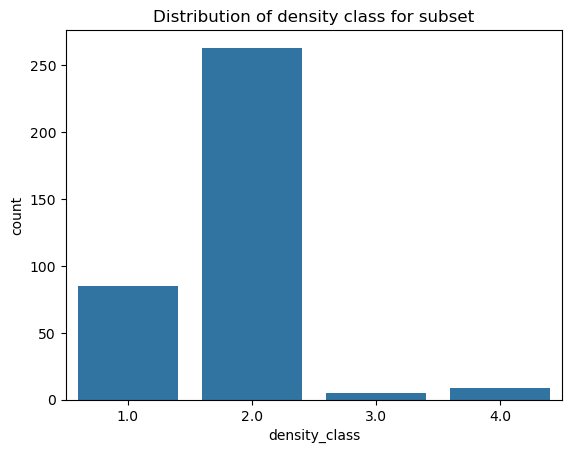

In [264]:
# density_class = category variable : usage of countplot rather than histplot
sns.countplot(x="density_class", data=insee_to_commune_subset)
plt.title("Distribution of density class for subset")
plt.show()

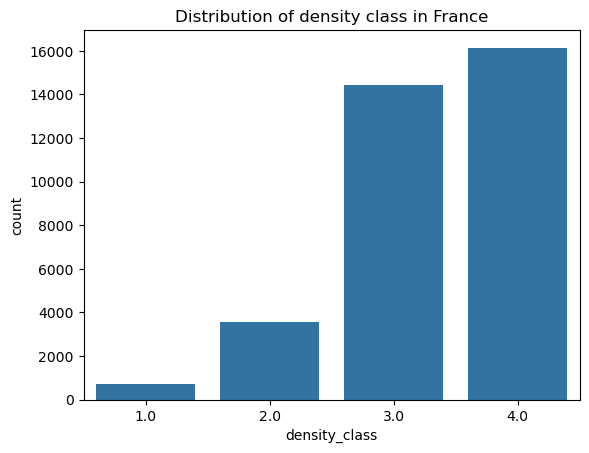

In [265]:
sns.countplot(x="density_class", data=insee_to_commune_global)
plt.title("Distribution of density class in France")
plt.show()

In [266]:
subset_density = (
    insee_to_commune["density_class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

full_density = (
    insee_to_commune_global["density_class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison = pd.DataFrame({
    "subset": subset_density,
    "full_france": full_density
})
comparison

,subset,full_france
density_class,,
1.0,23.480663,2.004301
2.0,72.651934,10.265233
3.0,1.381215,41.430824
4.0,2.486188,46.299642


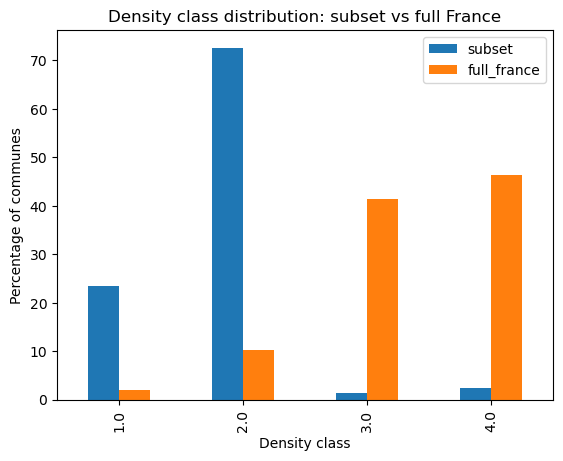

In [267]:
comparison.plot(kind="bar")
plt.title("Density class distribution: subset vs full France")
plt.ylabel("Percentage of communes")
plt.xlabel("Density class")
plt.show()

In [268]:
# OBSERVATION:
# The comparison clearly confirms that the 362-commune subset is not representative of the full set of French communes in terms of density profile.

# In the subset, density classes 1 and 2 (dense and intermediate urban communes) dominate overwhelmingly, whereas in the full national dataset, classes 3 and 4
# (peri-urban and rural communes) are the most represented.

# This indicates a strong urban selection bias in the restricted subset, likely driven by the data completeness constraint.

# As a result, analyses conducted on this subset should be interpreted as applying to a more urban and structurally denser perimeter, and not to French communes as a whole.

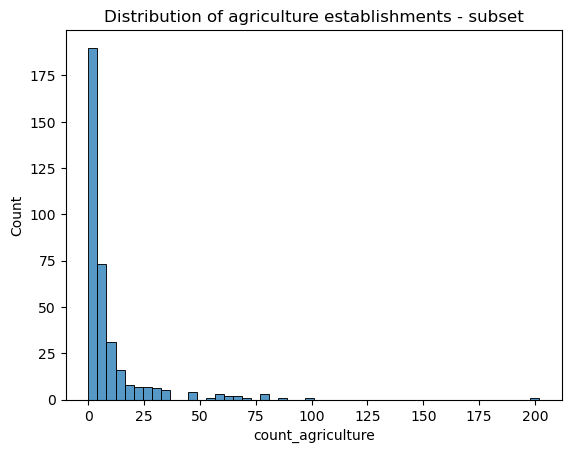

In [269]:
sns.histplot(insee_to_commune_subset["count_agriculture"], bins=50)
plt.title("Distribution of agriculture establishments - subset")
plt.show()

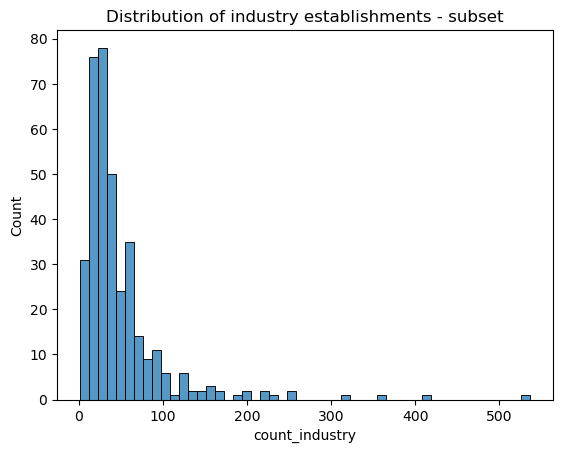

In [270]:
sns.histplot(insee_to_commune_subset["count_industry"], bins=50)
plt.title("Distribution of industry establishments - subset")
plt.show()

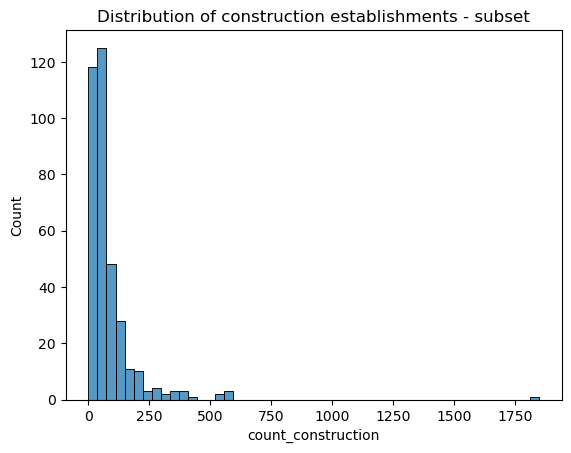

In [271]:
sns.histplot(insee_to_commune_subset["count_construction"], bins=50)
plt.title("Distribution of construction establishments - subset")
plt.show()

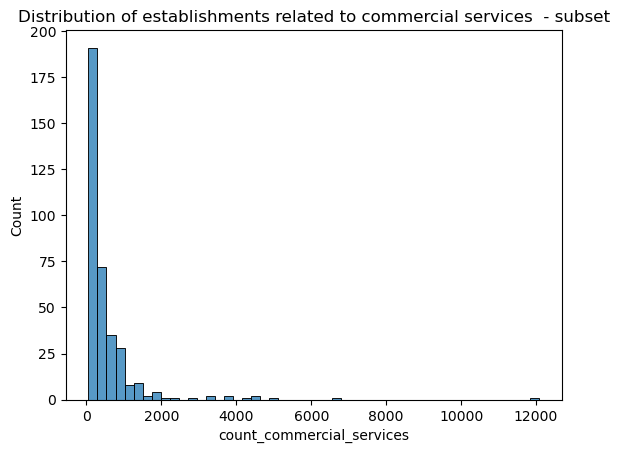

In [272]:
sns.histplot(insee_to_commune_subset["count_commercial_services"], bins=50)
plt.title("Distribution of establishments related to commercial services  - subset")
plt.show()

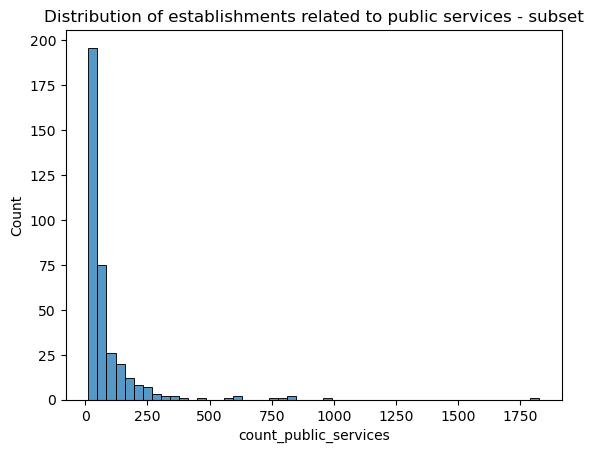

In [273]:
sns.histplot(insee_to_commune_subset["count_public_services"], bins=50)
plt.title("Distribution of establishments related to public services - subset")
plt.show()

In [274]:
# OBSERVATION:

# All establishment categories exhibit strongly right-skewed distributions.
# Most communes have relatively low numbers of establishments, while a small number of highly active communes drive the upper tail.

# This pattern is consistent across all sectors (industry, construction, commercial services and public services), although the magnitude varies.

# Commercial services show the highest dispersion, confirming their dominant role in local economic activity.

# Agriculture remains limited in most communes, with a few specialized territories.

# Analytical implication:
# The presence of strong asymmetry and outliers confirms that mean-based comparisons may be misleading. Robust statistics (e.g. median) or normalization should be preferred.

In [275]:
# ---------------------------------------
# d — outliers
# ---------------------------------------

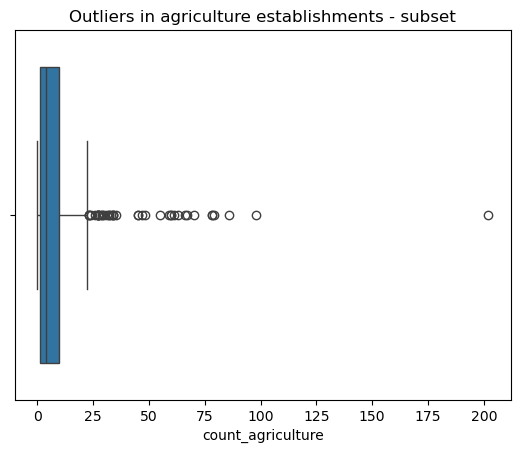

In [276]:
sns.boxplot(x=insee_to_commune_subset["count_agriculture"])
plt.title("Outliers in agriculture establishments - subset")
plt.show()

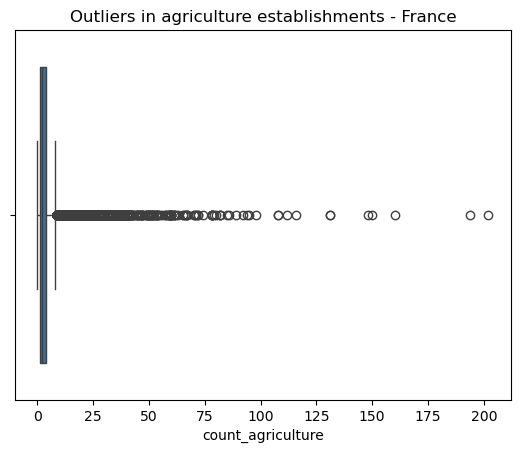

In [277]:
sns.boxplot(x=insee_to_commune_global["count_agriculture"])
plt.title("Outliers in agriculture establishments - France")
plt.show()

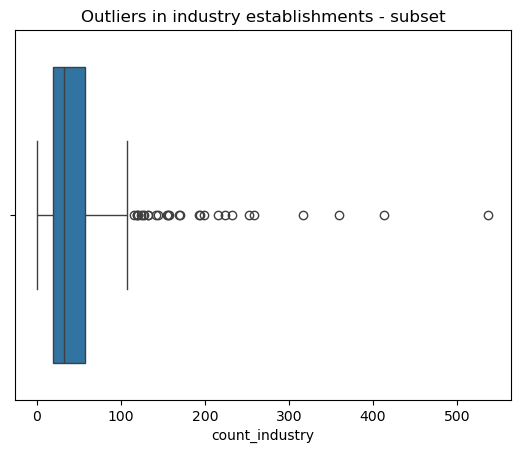

In [278]:
sns.boxplot(x=insee_to_commune_subset["count_industry"])
plt.title("Outliers in industry establishments - subset")
plt.show()

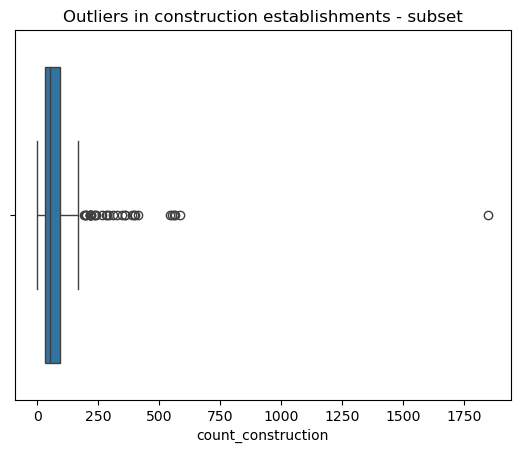

In [279]:
sns.boxplot(x=insee_to_commune_subset["count_construction"])
plt.title("Outliers in construction establishments - subset")
plt.show()

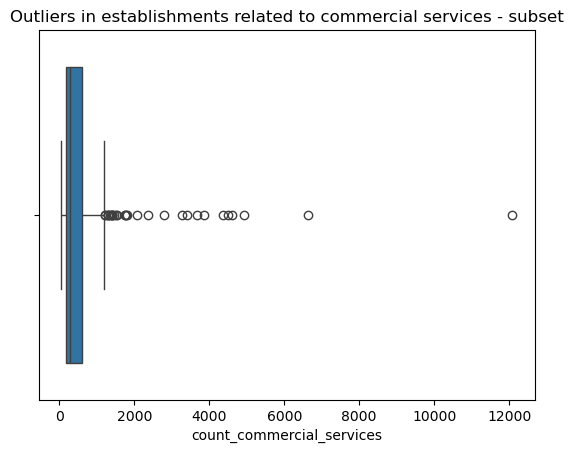

In [280]:
sns.boxplot(x=insee_to_commune_subset["count_commercial_services"])
plt.title("Outliers in establishments related to commercial services - subset")
plt.show()

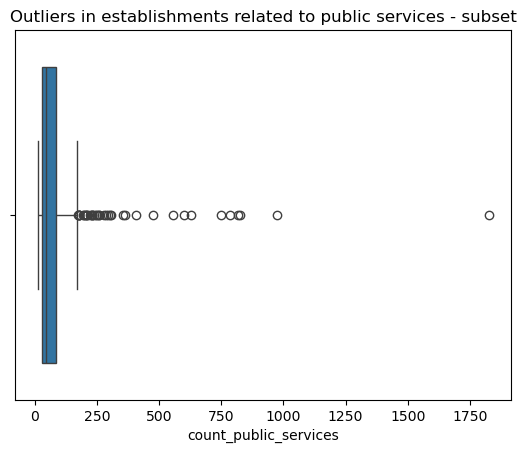

In [281]:
sns.boxplot(x=insee_to_commune_subset["count_public_services"])
plt.title("Outliers in establishments related to public services - subset")
plt.show()

In [282]:
# OBSERVATION:

# Boxplots confirm the presence of strong right-skewed distributions across all categories.
# A large number of outliers is observed in each sector, particularly for commercial services and construction.

# These outliers are not anomalies but reflect structurally highly active communes, likely corresponding to urban or economic centers.

# The concentration of values near the lower range, combined with numerous high-value outliers, highlights the strong heterogeneity between communes.

# AGRICULTURE-SPECIFIC OBSERVATION:
# In both the restricted subset and the full French commune dataset, agricultural establishments are highly concentrated near zero.

# This indicates that low agricultural activity is the dominant pattern, while a limited number of communes display much higher values,
# reflecting localized specialization in agricultural production.

# The same right-skewed structure is observed in both distributions, suggesting that this pattern is structural rather than specific to the subset.
# However, the subset contains fewer rural communes overall, so agricultural specialization is likely less represented than in the full national dataset.

# Analytical implication:
# Outliers should not be removed, as they carry meaningful information.  However, their presence reinforces the need for robust statistical measures (e.g. median) and normalization for comparative analysis.

In [283]:
# -----------------------------------------------------
# e — normalization and additionnal observations
# -----------------------------------------------------

In [284]:
# Normalize establishment counts per 1,000 inhabitants

# attention à la division par 0 !
print((insee_to_commune_subset["population_total"] == 0).sum())
print(insee_to_commune_subset["population_total"].isna().sum())

count_cols = [
    "count_agriculture",
    "count_industry",
    "count_construction",
    "count_commercial_services",
    "count_public_services",
    "total_count"
]

for col in count_cols:
    insee_to_commune_subset[f"{col}_per_1000"] = (
        insee_to_commune_subset[col] / insee_to_commune_subset["population_total"] * 1000
    )

insee_to_commune_subset.head()

0
0


,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count,count_agriculture_per_1000,count_industry_per_1000,count_construction_per_1000,count_commercial_services_per_1000,count_public_services_per_1000,total_count_per_1000
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,592.0,0.122407,2.019707,3.488586,25.154538,5.447090,36.232328
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,4.0,39.0,95.0,328.0,59.0,525.0,0.234866,2.289942,5.578064,19.258998,3.464271,30.826141
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,4.0,41.0,46.0,258.0,56.0,405.0,0.412584,4.228984,4.744714,26.611655,5.776173,41.774110
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,5.0,96.0,104.0,1517.0,304.0,2026.0,0.113737,2.183754,2.365733,34.507859,6.915220,46.086304
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,3.0,8.0,9.0,195.0,33.0,248.0,0.280820,0.748853,0.842460,18.253300,3.089020,23.214453


In [285]:
# attention à la division par 0 !
print((insee_to_commune_global["population_total"] == 0).sum())
insee_to_commune_global["population_total"].isna().sum()

6


np.int64(21)

In [286]:
count_cols = [
    "count_agriculture",
    "count_industry",
    "count_construction",
    "count_commercial_services",
    "count_public_services",
    "total_count"
]

valid_pop = insee_to_commune_global["population_total"] > 0

for col in count_cols:
    insee_to_commune_global[f"{col}_per_1000"] = np.nan
    insee_to_commune_global.loc[valid_pop, f"{col}_per_1000"] = (
        insee_to_commune_global.loc[valid_pop, col]
        / insee_to_commune_global.loc[valid_pop, "population_total"]
        * 1000
    )

In [287]:
# validation qu'aucune valeur infinie?

In [288]:
normalized_cols = [f"{col}_per_1000" for col in count_cols]
np.isinf(insee_to_commune_global[normalized_cols]).sum().sum()

np.int64(0)

In [289]:
insee_to_commune_global.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,total_count,count_agriculture_per_1000,count_industry_per_1000,count_construction_per_1000,count_commercial_services_per_1000,count_public_services_per_1000,total_count_per_1000
0,01001,Abergement-Clémenciat,876.0,4.0,Rural non périurbain,4.0,0.0,3.0,10.0,2.0,19.0,4.566210,0.000000,3.424658,11.415525,2.283105,21.689498
1,01002,Abergement-de-Varey,276.0,4.0,Rural non périurbain,1.0,0.0,0.0,2.0,1.0,4.0,3.623188,0.000000,0.000000,7.246377,3.623188,14.492754
2,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,592.0,0.122407,2.019707,3.488586,25.154538,5.447090,36.232328
3,01005,Ambérieux-en-Dombes,1930.0,3.0,Rural périurbain,2.0,4.0,10.0,25.0,8.0,49.0,1.036269,2.072539,5.181347,12.953368,4.145078,25.388601
4,01006,Ambléon,115.0,4.0,Rural non périurbain,0.0,0.0,0.0,0.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,8.695652,8.695652


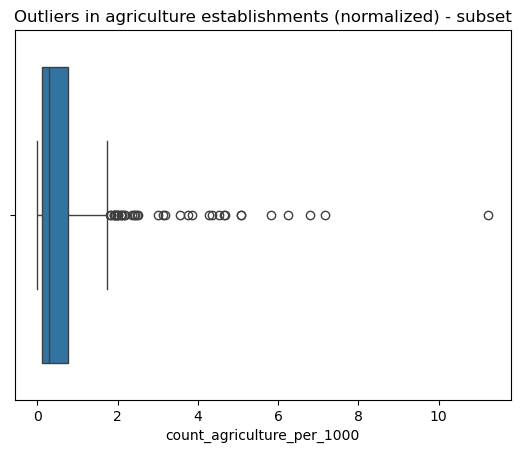

In [290]:
sns.boxplot(x=insee_to_commune_subset["count_agriculture_per_1000"])
plt.title("Outliers in agriculture establishments (normalized) - subset")
plt.show()

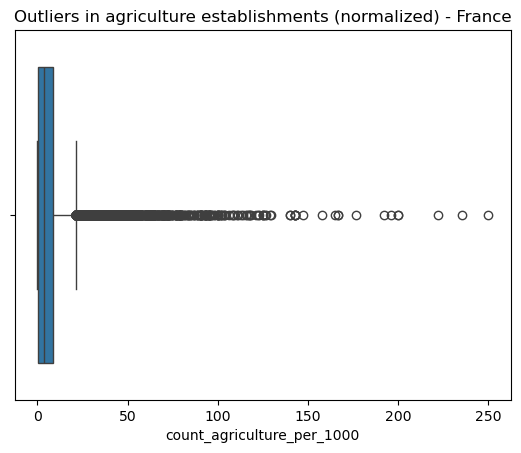

In [291]:
sns.boxplot(x=insee_to_commune_global["count_agriculture_per_1000"])
plt.title("Outliers in agriculture establishments (normalized) - France")
plt.show()

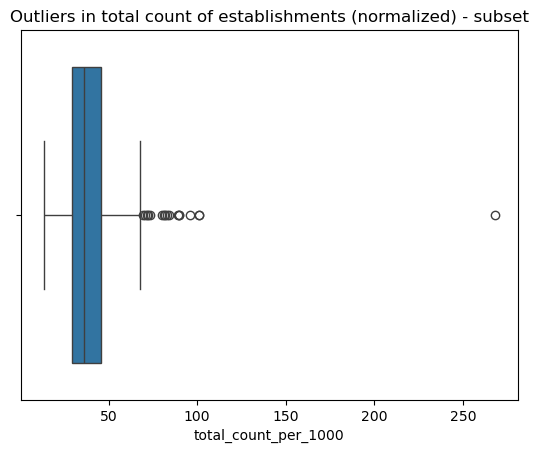

In [292]:
sns.boxplot(x=insee_to_commune_subset["total_count_per_1000"])
plt.title("Outliers in total count of establishments (normalized) - subset")
plt.show()

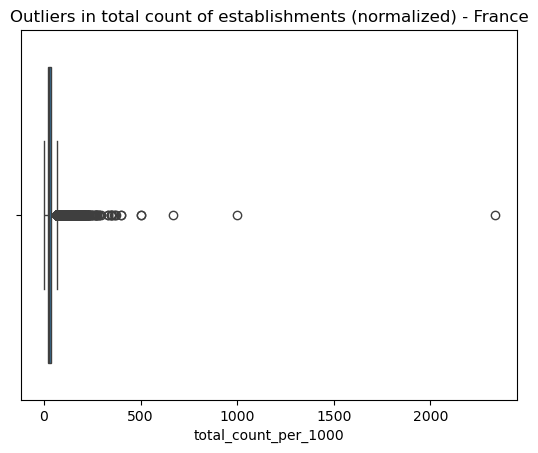

In [293]:
sns.boxplot(x=insee_to_commune_global["total_count_per_1000"])
plt.title("Outliers in total count of establishments (normalized) - France")
plt.show()

In [294]:
insee_to_commune_subset["total_count_per_1000"].describe()

count    362.000000
mean      39.941442
std       18.844102
min       13.555493
25%       29.602368
50%       36.141647
75%       45.507435
max      268.018635
Name: total_count_per_1000, dtype: float64

In [295]:
insee_to_commune_global["total_count_per_1000"].describe()

count    34485.000000
mean        31.366126
std         26.042254
min          0.000000
25%         18.681319
50%         26.315789
75%         37.293107
max       2333.333333
Name: total_count_per_1000, dtype: float64

In [296]:
# OBSERVATION:
# After normalization per 1,000 inhabitants, the subset still shows systematically higher values than the full national dataset, both in terms of median and quartiles.

# This indicates that the selected communes are not only larger, but also more economically active relative to their population.

# The full French dataset shows much greater dispersion and much more extreme maximum values, likely due to very small communes for which a limited number of establishments generates very high ratios.

# The subset therefore appears both more economically dense and more homogeneous than the full set of French communes.

In [297]:
# ============================================================
# B.2 — disposable_income_subset
# ============================================================

In [298]:
# here comparing income subset with the global France dataset would again be very interesting.

In [299]:
# access global income dataset
disposable_income_global = pd.read_csv(
    "cleaned_data/disposable_income_2021_clean.csv",
    sep=",",
    dtype={"iris_id": str}
)

disposable_income_global["iris_id"] = (
    disposable_income_global["iris_id"]
    .str.zfill(5)
)
disposable_income_global.head()

,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,010040101,Ambérieu-en-Bugey,Les Pérouses-Triangle d'Activités,19.0,14990.0,20350.0,26140.0,11620.0,32060.0,70.8,26.9,6.2,8.6,3.3,3.8,1.5,-12.5
1,010040102,Ambérieu-en-Bugey,Longeray-Gare,25.0,13880.0,18570.0,24760.0,10580.0,31130.0,70.6,24.9,5.8,11.1,3.7,5.1,2.3,-12.4
2,010040201,Ambérieu-en-Bugey,Centre-Saint-Germain-Vareilles,19.0,15190.0,20700.0,27180.0,11400.0,34450.0,72.5,27.2,6.4,7.7,2.8,3.3,1.6,-13.8
3,010040202,Ambérieu-en-Bugey,Tiret-Les Allymes,8.0,19600.0,25230.0,33170.0,14810.0,41230.0,73.3,23.8,16.2,4.0,1.8,1.5,0.7,-17.3
4,010330102,Valserhône,Centre Ville,24.0,14050.0,20420.0,29640.0,9410.0,42390.0,78.9,23.7,5.2,5.3,1.5,2.5,1.3,-13.1


In [300]:
# add a column insee_commune_id = first 5 characters of iris id - add it as first index comumn
disposable_income_global["insee_commune_id"] = disposable_income_global["iris_id"].astype(str).str[:5]

# Reorder columns to place insee_commune_id first
cols = ["insee_commune_id"] + [col for col in disposable_income_global.columns if col != "insee_commune_id"]
disposable_income_global = disposable_income_global[cols]

disposable_income_global.head()

,insee_commune_id,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,010040101,Ambérieu-en-Bugey,Les Pérouses-Triangle d'Activités,19.0,14990.0,20350.0,26140.0,11620.0,32060.0,70.8,26.9,6.2,8.6,3.3,3.8,1.5,-12.5
1,01004,010040102,Ambérieu-en-Bugey,Longeray-Gare,25.0,13880.0,18570.0,24760.0,10580.0,31130.0,70.6,24.9,5.8,11.1,3.7,5.1,2.3,-12.4
2,01004,010040201,Ambérieu-en-Bugey,Centre-Saint-Germain-Vareilles,19.0,15190.0,20700.0,27180.0,11400.0,34450.0,72.5,27.2,6.4,7.7,2.8,3.3,1.6,-13.8
3,01004,010040202,Ambérieu-en-Bugey,Tiret-Les Allymes,8.0,19600.0,25230.0,33170.0,14810.0,41230.0,73.3,23.8,16.2,4.0,1.8,1.5,0.7,-17.3
4,01033,010330102,Valserhône,Centre Ville,24.0,14050.0,20420.0,29640.0,9410.0,42390.0,78.9,23.7,5.2,5.3,1.5,2.5,1.3,-13.1


In [301]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [302]:
disposable_income_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   insee_commune_id                 2457 non-null   str    
 1   iris_id                          2457 non-null   str    
 2   commune_name                     2457 non-null   str    
 3   place_in_commune                 2457 non-null   str    
 4   taux_bas_revenus_pct             2457 non-null   float64
 5   revenu_q1_eur                    2457 non-null   float64
 6   revenu_median_eur                2457 non-null   float64
 7   revenu_q3_eur                    2457 non-null   float64
 8   revenu_d1_eur                    2457 non-null   float64
 9   revenu_d9_eur                    2457 non-null   float64
 10  part_revenus_activite_pct        2457 non-null   float64
 11  part_pensions_pct                2457 non-null   float64
 12  part_revenus_patrimoine_pct    

In [303]:
disposable_income_global.info()

<class 'pandas.DataFrame'>
RangeIndex: 14490 entries, 0 to 14489
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   insee_commune_id                 14490 non-null  str    
 1   iris_id                          14490 non-null  str    
 2   commune_name                     13115 non-null  str    
 3   place_in_commune                 14490 non-null  str    
 4   taux_bas_revenus_pct             14486 non-null  float64
 5   revenu_q1_eur                    14490 non-null  float64
 6   revenu_median_eur                14490 non-null  float64
 7   revenu_q3_eur                    14490 non-null  float64
 8   revenu_d1_eur                    14490 non-null  float64
 9   revenu_d9_eur                    14490 non-null  float64
 10  part_revenus_activite_pct        14490 non-null  float64
 11  part_pensions_pct                14490 non-null  float64
 12  part_revenus_patrimoine_pct  

In [304]:
disposable_income_global.isna().sum()

insee_commune_id                      0
iris_id                               0
commune_name                       1375
place_in_commune                      0
taux_bas_revenus_pct                  4
revenu_q1_eur                         0
revenu_median_eur                     0
revenu_q3_eur                         0
revenu_d1_eur                         0
revenu_d9_eur                         0
part_revenus_activite_pct             0
part_pensions_pct                     0
part_revenus_patrimoine_pct           0
part_prestations_sociales_pct         0
part_prestations_familiales_pct       0
part_minima_sociaux_pct               0
part_prestations_logement_pct         0
part_impots_pct                       0
dtype: int64

In [305]:
# OBSERVATION:
# The disposable income subset is fully complete across all variables, making it directly suitable for exploratory analysis and aggregation.

# The global disposable income dataset is also almost complete.
# Only 'commune_name' has a limited number of missing values, which does not affect analysis as the geographic key is 'insee_commune_id'.
# 'taux_bas_revenus_pct' has 4 missing values only, which is negligible at this stage.

In [306]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [307]:
disposable_income_subset.describe()

,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
count,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000
mean,17.916565,16801.021571,22814.021164,30352.169312,12232.205942,40060.492470,69.836589,29.782865,8.903378,7.075336,2.216646,3.328490,1.530199,-15.598168
std,10.806182,3333.620083,4535.345143,6702.100998,2428.466766,10936.670976,9.788245,7.595862,5.888082,5.398825,1.635228,2.714365,1.288640,4.038874
min,3.000000,9680.000000,12270.000000,15030.000000,5630.000000,18850.000000,24.100000,5.800000,0.900000,0.600000,0.100000,0.200000,0.100000,-34.000000
25%,10.000000,14370.000000,20030.000000,26300.000000,10410.000000,33320.000000,63.800000,24.800000,5.400000,3.500000,1.200000,1.500000,0.600000,-17.800000
50%,15.000000,16690.000000,22600.000000,29580.000000,12060.000000,37860.000000,70.800000,29.100000,7.600000,5.500000,1.800000,2.500000,1.100000,-15.200000
75%,23.000000,19130.000000,25440.000000,33420.000000,13830.000000,44340.000000,76.500000,34.000000,10.800000,8.600000,2.600000,4.200000,2.000000,-13.000000
max,67.000000,32430.000000,51650.000000,79590.000000,23230.000000,119750.000000,103.100000,68.400000,84.500000,36.100000,11.700000,19.500000,8.500000,-5.400000


In [308]:
disposable_income_global.describe()

,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
count,14486.00000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000
mean,19.18114,16850.935128,23256.781228,31399.986888,12085.857833,42000.580400,73.208468,27.128399,8.077654,7.938772,2.380559,3.831056,1.727157,-16.353292
std,12.01795,4085.602812,6199.841365,9826.027129,2714.333510,16890.263892,12.820126,8.916848,6.547103,6.451478,1.826778,3.395585,1.504497,5.692465
min,3.00000,7290.000000,10860.000000,13350.000000,2850.000000,15500.000000,21.800000,-0.400000,0.600000,0.200000,0.100000,0.100000,0.000000,-50.600000
25%,10.00000,13760.000000,19170.000000,25510.000000,10030.000000,32482.500000,64.400000,20.800000,4.300000,3.600000,1.200000,1.500000,0.700000,-19.000000
50%,16.00000,16380.000000,22380.000000,29410.000000,11770.000000,37850.000000,73.300000,26.400000,6.500000,6.000000,1.900000,2.800000,1.300000,-15.300000
75%,25.00000,19280.000000,25997.500000,34630.000000,13750.000000,46130.000000,82.200000,32.700000,9.600000,10.200000,3.000000,5.000000,2.300000,-12.600000
max,81.00000,36300.000000,65140.000000,135380.000000,28280.000000,269870.000000,113.200000,69.400000,84.500000,57.300000,16.000000,33.500000,13.800000,-3.500000


In [309]:
# OBSERVATION: 
# The similarity between the disposable income subset and the so-called "global" disposable income dataset is not unexpected. 
# The reason is that the "global" income dataset does not represent all French communes, but rather all IRIS units for which income data is available. 

# As a result, it is likely already biased toward: 
# - larger communes 
# - more urban communes 
# - communes divided into multiple IRIS units 
# - and, more generally, communes with better statistical coverage 

# In other words, the 362-commune subset may itself be a subset of an already selected population. 
# It is therefore logical that both datasets appear more similar to each other than, for example, insee_to_commune_subset and insee_to_commune_global. 
# A key methodological risk would be to assess commune-level representativeness directly from IRIS-level income tables. 
# This would be misleading, because larger communes contain more IRIS units and therefore mechanically carry more weight in the distributions. 
# Representativeness should therefore be assessed at commune level, not at IRIS level.

In [310]:
# income data representativeness analysis

In [311]:
income_communes_global = disposable_income_global[["insee_commune_id"]].drop_duplicates()
income_communes_subset = disposable_income_subset[["insee_commune_id"]].drop_duplicates()

print("Unique communes in income global:", income_communes_global["insee_commune_id"].nunique())
print("Unique communes in income subset:", income_communes_subset["insee_commune_id"].nunique())
print("Unique communes in reference table:", insee_to_commune_global["insee_commune_id"].nunique())

Unique communes in income global: 1886
Unique communes in income subset: 362
Unique communes in reference table: 34876


In [312]:
income_global_coverage_rate = (
    income_communes_global["insee_commune_id"].nunique()
    / insee_to_commune_global["insee_commune_id"].nunique()
    *100
)

income_subset_coverage_rate = (
    income_communes_subset["insee_commune_id"].nunique()
    / insee_to_commune_global["insee_commune_id"].nunique()
    *100
)

print("Coverage rate - income global:", income_global_coverage_rate)
print("Coverage rate - income subset:", income_subset_coverage_rate)

Coverage rate - income global: 5.40773024429407
Coverage rate - income subset: 1.0379630691593071


In [313]:
#is it biased by density?

In [314]:
income_communes_global["has_income_global"] = True

ref_with_income = insee_to_commune_global.merge(
    income_communes_global,
    on="insee_commune_id",
    how="left"
)

ref_with_income["has_income_global"] = ref_with_income["has_income_global"].fillna(False)

density_full = (
    ref_with_income["density_class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

density_income_global = (
    ref_with_income.loc[ref_with_income["has_income_global"], "density_class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

density_comparison = pd.DataFrame({
    "full_france": density_full,
    "income_global": density_income_global
})

density_comparison

,full_france,income_global
density_class,,
1.0,2.004301,32.317737
2.0,10.265233,59.194777
3.0,41.430824,3.862894
4.0,46.299642,4.624592


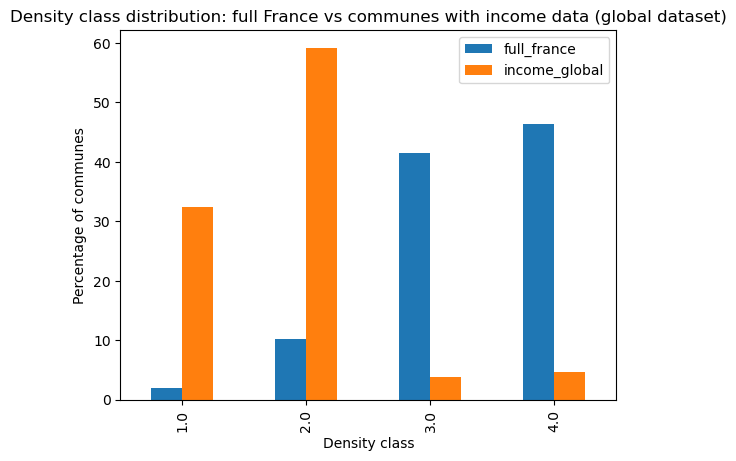

In [315]:
density_comparison.plot(kind="bar")
plt.title("Density class distribution: full France vs communes with income data (global dataset)")
plt.ylabel("Percentage of communes")
plt.xlabel("Density class")
plt.show()

In [316]:
# OBSERVATION:
# The commune-level comparison confirms that the so-called "global" disposable income dataset is itself strongly biased and cannot be considered representative of French communes as a whole.

# Compared with the full French commune reference table, communes with income data are massively overrepresented in density classes 1 and 2 (dense and intermediate urban areas),
# and massively underrepresented in classes 3 and 4 (peri-urban and rural communes).

# This indicates a strong structural urban selection bias in the income dataset itself.

# As a consequence, the 362-commune subset should be interpreted as a subset of an already highly selected urban-oriented population, rather than as a restricted version
# of the full French commune dataset.

# Any analysis based on these income data should therefore be interpreted within this restricted perimeter only, and not generalized to all French communes.

# We will now fully work on the 362 communes income subset as it anyhow biased the same way as the global income dataset.

In [317]:
# ---------------------------------------
# c — distribution and outliers
# ---------------------------------------

In [318]:
disposable_income_subset.head()

,insee_commune_id,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,010040101,Ambérieu-en-Bugey,Les Pérouses-Triangle d'Activités,19.0,14990.0,20350.0,26140.0,11620.0,32060.0,70.8,26.9,6.2,8.6,3.3,3.8,1.5,-12.5
1,01004,010040102,Ambérieu-en-Bugey,Longeray-Gare,25.0,13880.0,18570.0,24760.0,10580.0,31130.0,70.6,24.9,5.8,11.1,3.7,5.1,2.3,-12.4
2,01004,010040201,Ambérieu-en-Bugey,Centre-Saint-Germain-Vareilles,19.0,15190.0,20700.0,27180.0,11400.0,34450.0,72.5,27.2,6.4,7.7,2.8,3.3,1.6,-13.8
3,01004,010040202,Ambérieu-en-Bugey,Tiret-Les Allymes,8.0,19600.0,25230.0,33170.0,14810.0,41230.0,73.3,23.8,16.2,4.0,1.8,1.5,0.7,-17.3
4,01033,010330102,Valserhône,Centre Ville,24.0,14050.0,20420.0,29640.0,9410.0,42390.0,78.9,23.7,5.2,5.3,1.5,2.5,1.3,-13.1


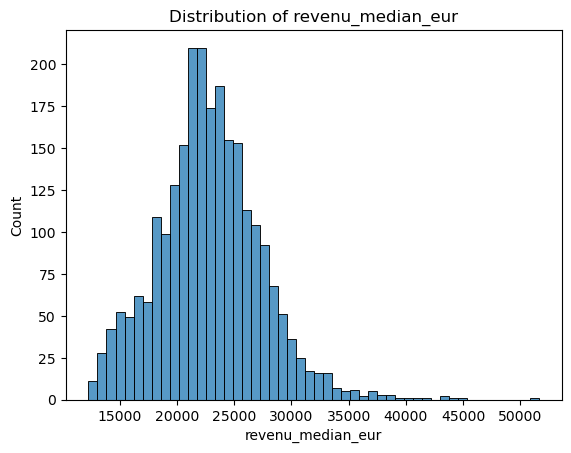

In [319]:
sns.histplot(disposable_income_subset["revenu_median_eur"], bins=50)
plt.title("Distribution of revenu_median_eur")
plt.show()

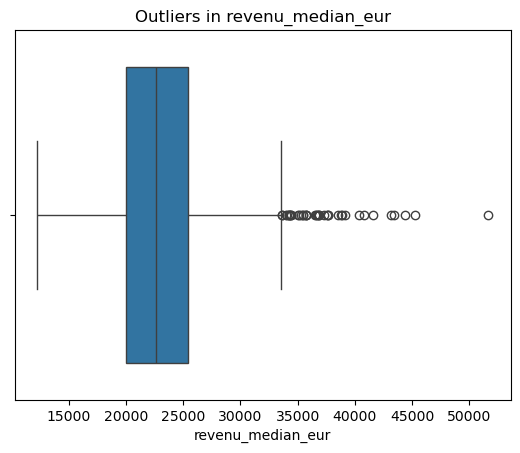

In [320]:
sns.boxplot(x=disposable_income_subset["revenu_median_eur"])
plt.title("Outliers in revenu_median_eur")
plt.show()

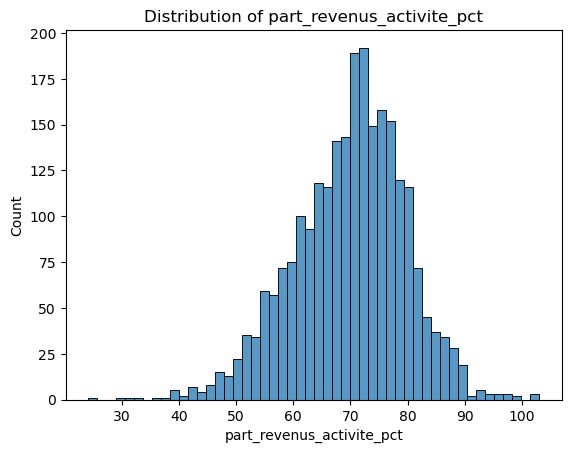

In [321]:
sns.histplot(disposable_income_subset["part_revenus_activite_pct"], bins=50)
plt.title("Distribution of part_revenus_activite_pct")
plt.show()

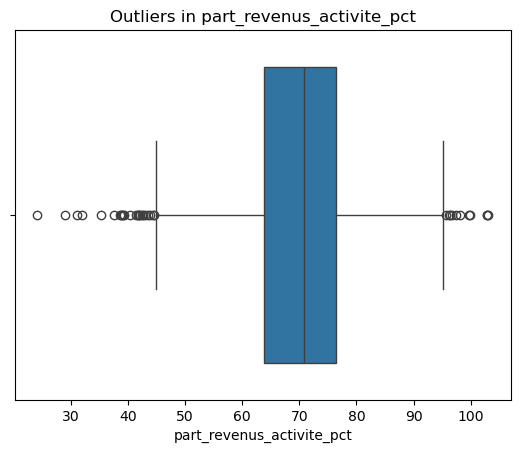

In [322]:
sns.boxplot(x=disposable_income_subset["part_revenus_activite_pct"])
plt.title("Outliers in part_revenus_activite_pct")
plt.show()

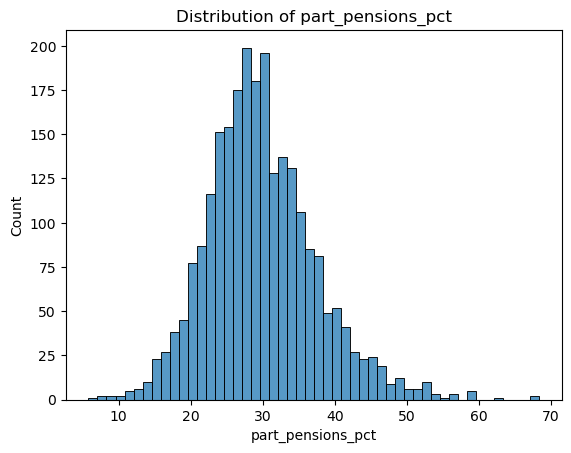

In [323]:
sns.histplot(disposable_income_subset["part_pensions_pct"], bins=50)
plt.title("Distribution of part_pensions_pct")
plt.show()

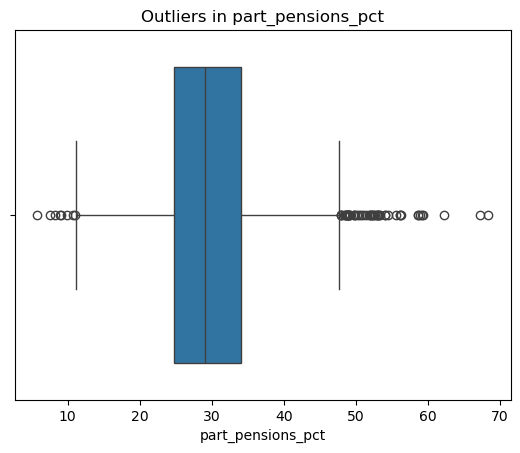

In [324]:
sns.boxplot(x=disposable_income_subset["part_pensions_pct"])
plt.title("Outliers in part_pensions_pct")
plt.show()

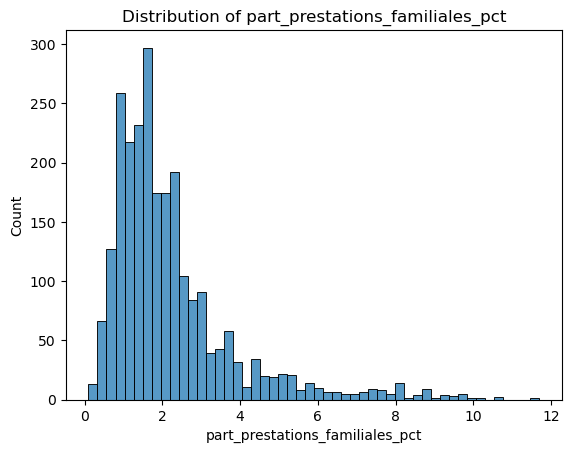

In [325]:
sns.histplot(disposable_income_subset["part_prestations_familiales_pct"], bins=50)
plt.title("Distribution of part_prestations_familiales_pct")
plt.show()

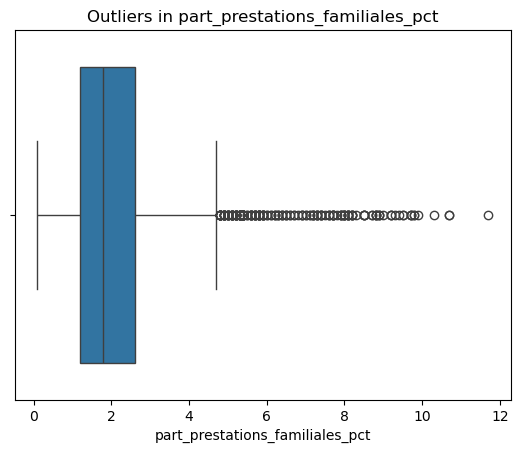

In [326]:
sns.boxplot(x=disposable_income_subset["part_prestations_familiales_pct"])
plt.title("Outliers in part_prestations_familiales_pct")
plt.show()

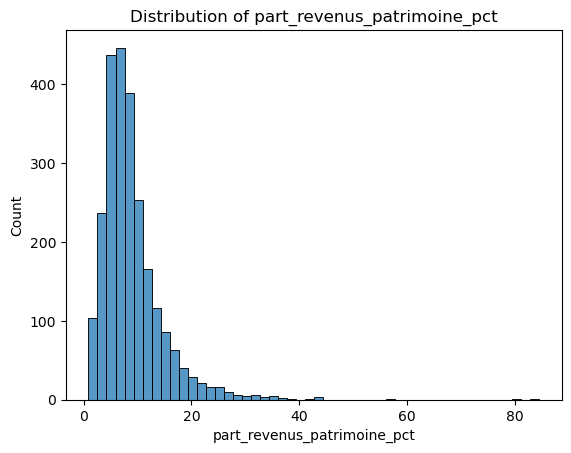

In [327]:
sns.histplot(disposable_income_subset["part_revenus_patrimoine_pct"], bins=50)
plt.title("Distribution of part_revenus_patrimoine_pct")
plt.show()

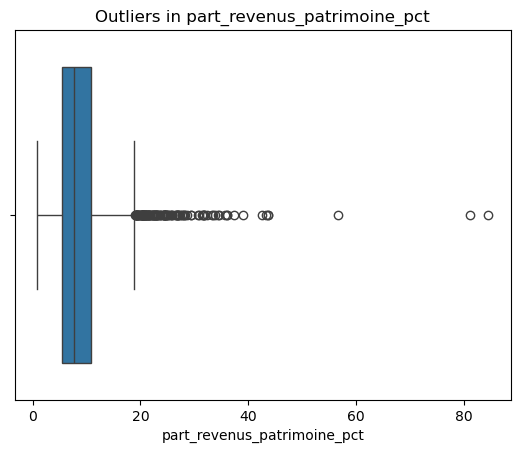

In [328]:
sns.boxplot(x=disposable_income_subset["part_revenus_patrimoine_pct"])
plt.title("Outliers in part_revenus_patrimoine_pct")
plt.show()

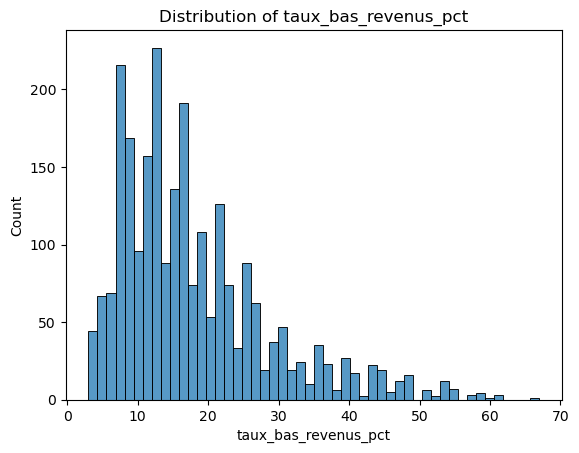

In [329]:
sns.histplot(disposable_income_subset["taux_bas_revenus_pct"], bins=50)
plt.title("Distribution of taux_bas_revenus_pct")
plt.show()

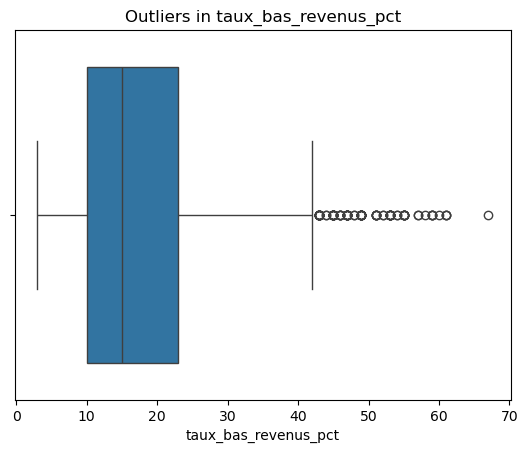

In [330]:
sns.boxplot(x=disposable_income_subset["taux_bas_revenus_pct"])
plt.title("Outliers in taux_bas_revenus_pct")
plt.show()

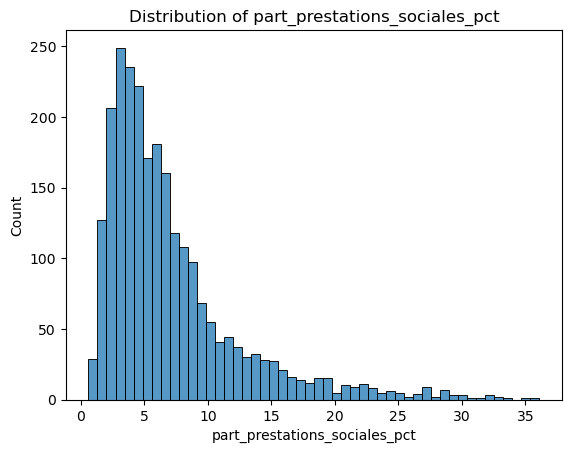

In [331]:
sns.histplot(disposable_income_subset["part_prestations_sociales_pct"], bins=50)
plt.title("Distribution of part_prestations_sociales_pct")
plt.show()

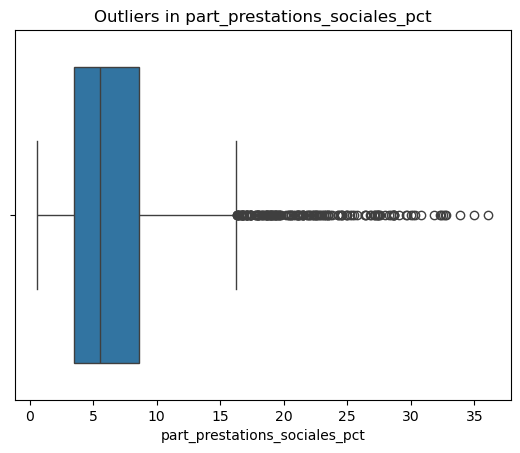

In [332]:
sns.boxplot(x=disposable_income_subset["part_prestations_sociales_pct"])
plt.title("Outliers in part_prestations_sociales_pct")
plt.show()

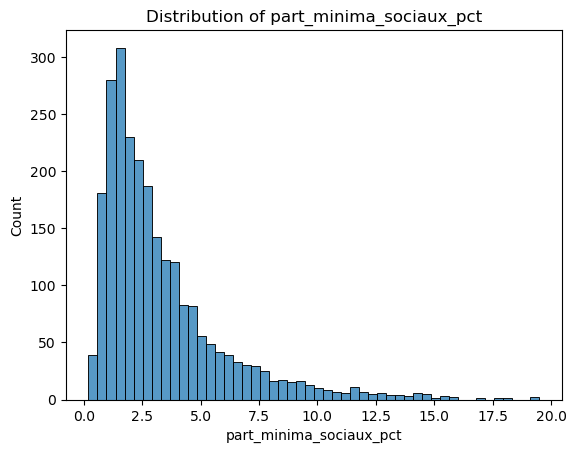

In [333]:
sns.histplot(disposable_income_subset["part_minima_sociaux_pct"], bins=50)
plt.title("Distribution of part_minima_sociaux_pct")
plt.show()

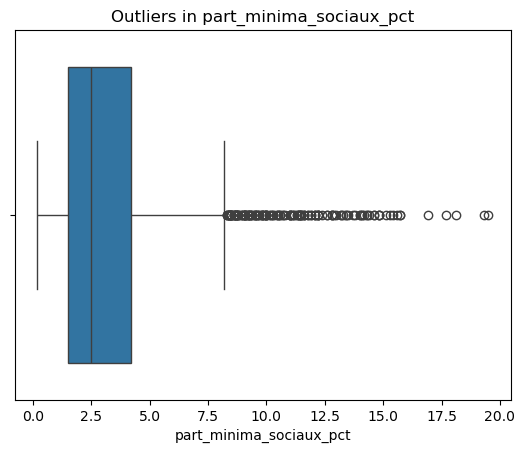

In [334]:
sns.boxplot(x=disposable_income_subset["part_minima_sociaux_pct"])
plt.title("Outliers in part_minima_sociaux_pct")
plt.show()

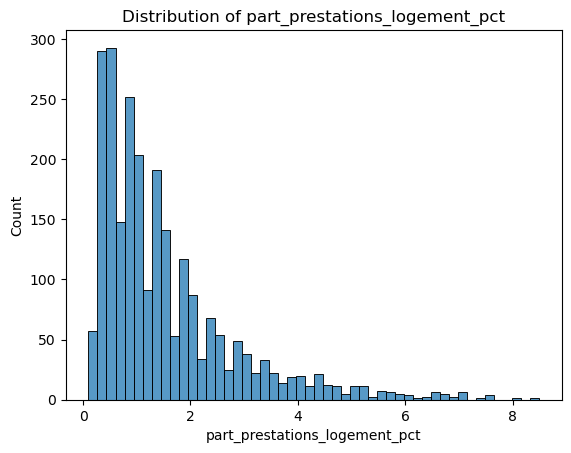

In [335]:
sns.histplot(disposable_income_subset["part_prestations_logement_pct"], bins=50)
plt.title("Distribution of part_prestations_logement_pct")
plt.show()

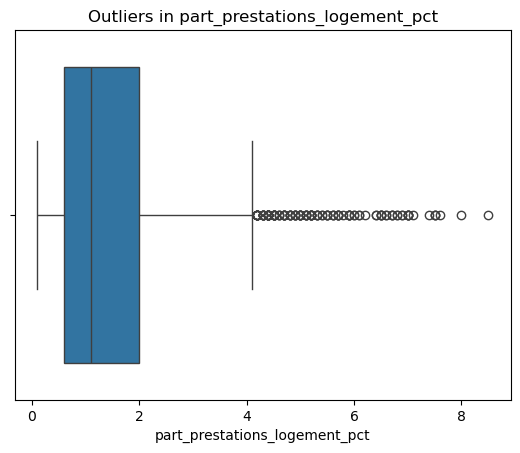

In [336]:
sns.boxplot(x=disposable_income_subset["part_prestations_logement_pct"])
plt.title("Outliers in part_prestations_logement_pct")
plt.show()

In [337]:
# OBSERVATION: 
# The income-related variables do not follow a single common pattern. They can be grouped into two main distribution types. 
#
# 1. Relatively central and moderately dispersed variables: 
# - revenu_median_eur 
# - part_revenus_activite_pct 
# - part_pensions_pct 
#
# revenu_median_eur is concentrated around an intermediate core, with a moderate right tail and a limited number of higher-income outliers. 
# part_revenus_activite_pct is the most concentrated variable, close to a bell-shaped distribution, showing that labour income is the dominant source of income in most IRIS. 
# part_pensions_pct is also relatively concentrated, although with a moderate right tail, indicating higher pension dependence in a smaller number of IRIS. 

# 2. Strongly right-skewed social and patrimonial indicators: 
# - part_prestations_familiales_pct 
# - part_revenus_patrimoine_pct 
# - taux_bas_revenus_pct 
# - part_prestations_sociales_pct 
# - part_minima_sociaux_pct 
# - part_prestations_logement_pct 
#
# These variables show a clear concentration at low-to-moderate values, combined with long right tails and numerous upper outliers. 
# This indicates that higher levels of social transfers, low-income households, housing benefits, minimum social benefits, or patrimonial income 
# are not evenly distributed across the subset, but concentrated in a limited number of IRIS. 
# Boxplots confirm that these outliers should not be interpreted as data errors. They are meaningful observations and likely reflect localized socio-economic profiles, 
# such as areas with stronger social vulnerability, retirement dependence, or higher concentration of patrimonial income. 

# Analytical implication: 
# Median income alone is not sufficient to describe socio-economic differences across IRIS. 
# Variables related to income composition and social transfers provide essential complementary information to capture territorial heterogeneity and localized vulnerability.

In [338]:
# -------------------------------------------------
# d — Correlation analysis
# -------------------------------------------------

<Axes: >

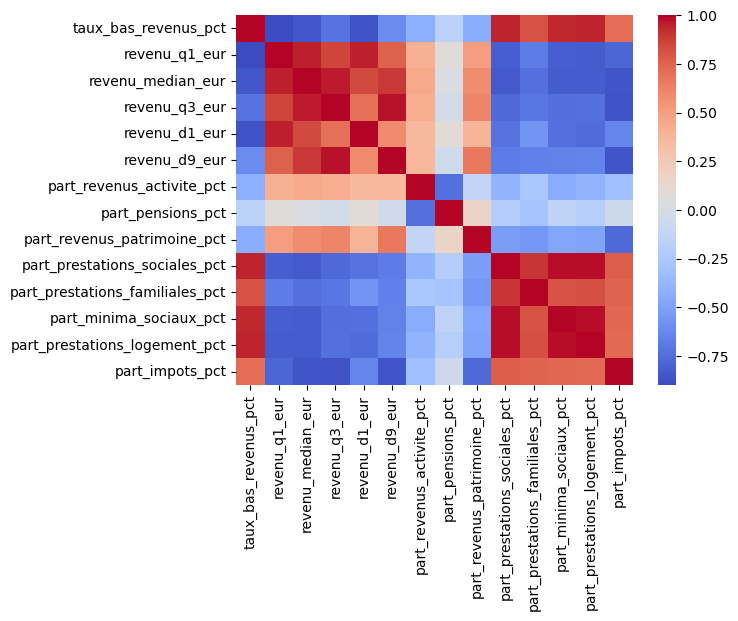

In [339]:
sns.heatmap(disposable_income_subset.corr(numeric_only=True), cmap="coolwarm")

In [340]:
# OBSERVATION:
# The correlation heatmap reveals a clear block structure within the income dataset.

# A first block groups together the different income level indicators (revenu_q1_eur, revenu_median_eur, revenu_q3_eur, revenu_d1_eur, revenu_d9_eur),
# which are all strongly positively correlated.

# A second block groups together the main social vulnerability indicators, including low-income rate, social benefits, minimum social benefits,
# housing benefits, and family benefits, which also show strong positive correlations.

# These two blocks are strongly opposed:
# higher income levels are associated with lower shares of social transfers and lower low-income rates, while higher social vulnerability indicators
# tend to be associated with lower income levels.

# part_revenus_activite_pct appears relatively distinct, with negative relationships to several social vulnerability indicators,
# suggesting an opposition between labour-income-dominated IRIS and transfer-dependent IRIS.

# part_revenus_patrimoine_pct shows a more specific profile, appearing more closely related to the upper part of the income distribution
# than to the main social transfer indicators.

# Analytical implication:
# The heatmap suggests that a limited number of variables may capture the main socio-economic structure of the dataset,
# with one axis related to income level and another related to social vulnerability.

In [341]:
# Deeper correlation analysis : 

In [342]:
# 1 - taux_bas_revenus_pct × part_prestations_sociales_pct

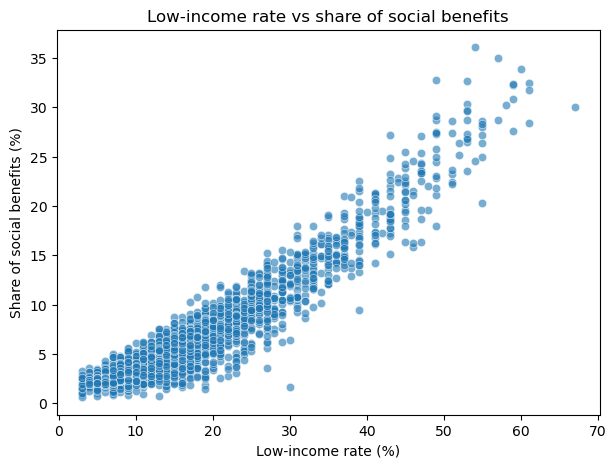

In [343]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=disposable_income_subset,
    x="taux_bas_revenus_pct",
    y="part_prestations_sociales_pct",
    alpha=0.6
)
plt.title("Low-income rate vs share of social benefits")
plt.xlabel("Low-income rate (%)")
plt.ylabel("Share of social benefits (%)")
plt.show()

In [344]:
# 2 - revenu_d9_eur × part_revenus_patrimoine_pct

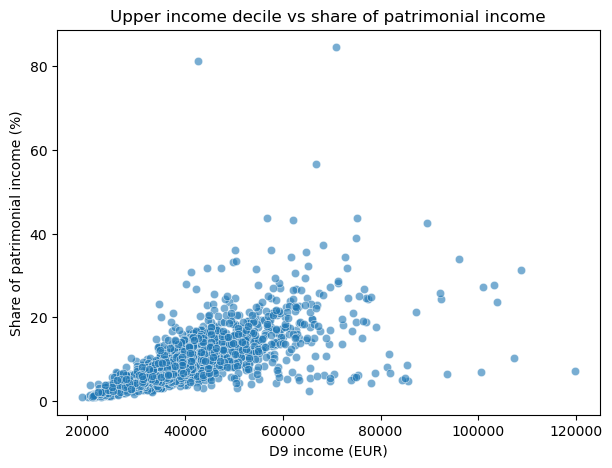

In [345]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=disposable_income_subset,
    x="revenu_d9_eur",
    y="part_revenus_patrimoine_pct",
    alpha=0.6
)
plt.title("Upper income decile vs share of patrimonial income")
plt.xlabel("D9 income (EUR)")
plt.ylabel("Share of patrimonial income (%)")
plt.show()

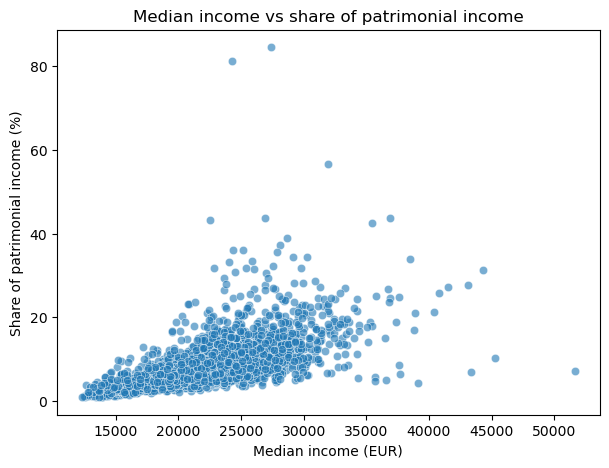

In [346]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=disposable_income_subset,
    x="revenu_median_eur",
    y="part_revenus_patrimoine_pct",
    alpha=0.6
)
plt.title("Median income vs share of patrimonial income")
plt.xlabel("Median income (EUR)")
plt.ylabel("Share of patrimonial income (%)")
plt.show()

In [347]:
# 3 - part_revenus_activite_pct × revenu_median_eur

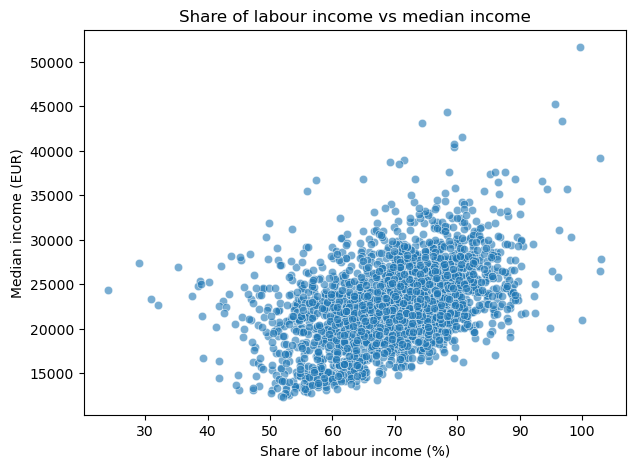

In [348]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=disposable_income_subset,
    x="part_revenus_activite_pct",
    y="revenu_median_eur",
    alpha=0.6
)
plt.title("Share of labour income vs median income")
plt.xlabel("Share of labour income (%)")
plt.ylabel("Median income (EUR)")
plt.show()

In [349]:
# 4 - part_revenus_activite_pct × part_minima_sociaux_pct

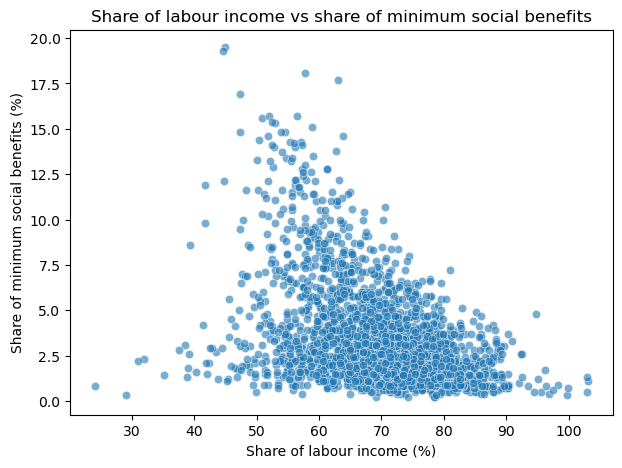

In [350]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=disposable_income_subset,
    x="part_revenus_activite_pct",
    y="part_minima_sociaux_pct",
    alpha=0.6
)
plt.title("Share of labour income vs share of minimum social benefits")
plt.xlabel("Share of labour income (%)")
plt.ylabel("Share of minimum social benefits (%)")
plt.show()

In [351]:
# OBSERVATION:
# ------------------------
# The four selected scatter plots reveal a coherent socio-economic structure within the disposable income subset.

# 1. Low-income rate vs share of social benefits:
# A strong positive relationship is observed between taux_bas_revenus_pct and part_prestations_sociales_pct.
# IRIS with higher shares of low-income households also tend to show higher dependence on social transfers.

# 2. Upper income decile vs share of patrimonial income:
# A positive but much more dispersed relationship appears between revenu_d9_eur and part_revenus_patrimoine_pct.
# Higher upper-income levels tend to be associated with a larger share of patrimonial income, but the relationship is less systematic
# and includes several high-value outliers.

# 3. Share of labour income vs median income: 
# A moderate positive relationship is visible between part_revenus_activite_pct and revenu_median_eur. 
# IRIS with a higher share of labour income generally tend to display higher median income, although dispersion remains substantial. 

# 4. Share of labour income vs share of minimum social benefits: 
# A clear negative relationship is observed between part_revenus_activite_pct and part_minima_sociaux_pct. 
# IRIS more strongly driven by labour income tend to show lower dependence on minimum social benefits. 

# Overall interpretation: 
# ------------------------
# These relationships highlight two main socio-economic axis: 
# - a social vulnerability axis, linking low-income rates and social transfer dependence 
# - an income composition axis, opposing IRIS where income mainly comes from labour to IRIS where income depends more on social transfers or patrimonial income

# This confirms that median income alone is not sufficient to characterize socio-economic profiles across IRIS. Income composition and social transfer indicators bring essential complementary information.

In [352]:
# ============================================================
# B.3 — crime_subset
# ============================================================

In [353]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [354]:
crime_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 48870 entries, 0 to 48869
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   insee_commune_id  48870 non-null  str    
 1   annee             48870 non-null  int64  
 2   crime_type        48870 non-null  str    
 3   unite_de_compte   48870 non-null  str    
 4   nombre            38308 non-null  float64
 5   taux_pour_mille   38308 non-null  float64
 6   insee_pop_ref     48870 non-null  int64  
 7   data_available    48870 non-null  bool   
dtypes: bool(1), float64(2), int64(2), str(3)
memory usage: 2.7 MB


In [355]:
crime_subset.isna().sum()

insee_commune_id        0
annee                   0
crime_type              0
unite_de_compte         0
nombre              10562
taux_pour_mille     10562
insee_pop_ref           0
data_available          0
dtype: int64

In [356]:
crime_subset["crime_type"].value_counts()

crime_type
Violences physiques intrafamiliales               3258
Violences physiques hors cadre familial           3258
Violences sexuelles                               3258
Vols avec armes                                   3258
Vols violents sans arme                           3258
Vols sans violence contre des personnes           3258
Cambriolages de logement                          3258
Vols de véhicule                                  3258
Vols dans les véhicules                           3258
Vols d'accessoires sur véhicules                  3258
Destructions et dégradations volontaires          3258
Usage de stupéfiants                              3258
Usage de stupéfiants (AFD)                        3258
Trafic de stupéfiants                             3258
Escroqueries et fraudes aux moyens de paiement    3258
Name: count, dtype: int64

In [357]:
# Create a pivot table to reshape the dataset from long to wide format,turning crime_type values into columns for both counts and rates per 1,000 inhabitants.
crime_wide = (
    crime_subset
    .pivot(
        index=["insee_commune_id", "annee"],
        columns="crime_type",
        values=["nombre", "taux_pour_mille"]
    )
    .reset_index()
)

crime_wide.head()

insee_commune_id annee                   nombre  \
crime_type                        Cambriolages de logement   
0                     01004  2016                     72.0   
1                     01004  2017                     60.0   
2                     01004  2018                     48.0   
3                     01004  2019                     76.0   
4                     01004  2020                     37.0   

                                                     \
crime_type Destructions et dégradations volontaires   
0                                             116.0   
1                                             110.0   
2                                             150.0   
3                                             138.0   
4                                             134.0   

                                                           \
crime_type Escroqueries et fraudes aux moyens de paiement   
0                                                    48.0   
1                                                    54.0   
2                                                    54.0   
3                                                    55.0   
4                                                    71.0   

                                                       \
crime_type Trafic de stupéfiants Usage de stupéfiants   
0                           44.0                 29.0   
1                            8.0                 27.0   
2                            8.0                 35.0   
3                            5.0                 47.0   
4                           21.0                 74.0   

                                                                               \
crime_type Usage de stupéfiants (AFD) Violences physiques hors cadre familial   
0                                 0.0                                    53.0   
1                                 0.0                                    54.0   
2                                 0.0                                    60.0   
3                                 0.0                                    79.0   
4                                 8.0                                    68.0   

                                                ...  \
crime_type Violences physiques intrafamiliales  ...   
0                                         28.0  ...   
1                                         44.0  ...   
2                                         51.0  ...   
3                                         54.0  ...   
4                                         44.0  ...   

                      taux_pour_mille                                          \
crime_type Usage de stupéfiants (AFD) Violences physiques hors cadre familial   
0                             0.00000                                3.763937   
1                             0.00000                                3.847524   
2                             0.00000                                4.224162   
3                             0.00000                                5.589359   
4                             0.55991                                4.759239   

                                                                    \
crime_type Violences physiques intrafamiliales Violences sexuelles   
0                                     1.988495            0.923230   
1                                     3.135020            0.855005   
2                                     3.590538            1.619262   
3                                     3.820575            1.415028   
4                                     3.079507            1.609742   

                                                             \
crime_type Vols avec armes Vols d'accessoires sur véhicules   
0                      NaN                         1.562389   
1                      NaN                         1.995013   
2                      NaN                         1.196846   
3                      NaN        

In [358]:
# Flatten the multi-level columns created by the pivot to get back to a standard dataset structure.

In [359]:
new_columns = []

for col in crime_wide.columns:
    if isinstance(col, tuple):
        level_0, level_1 = col

        if level_0 == "nombre":
            new_col = f"{level_1}_count"
        elif level_0 == "taux_pour_mille":
            new_col = f"{level_1}_per_1000"
        else:
            new_col = f"{level_0}_{level_1}" if level_1 else level_0
    else:
        new_col = col

    new_columns.append(new_col)

crime_wide.columns = new_columns

crime_wide.head()

,insee_commune_id,annee,Cambriolages de logement_count,Destructions et dégradations volontaires_count,Escroqueries et fraudes aux moyens de paiement_count,Trafic de stupéfiants_count,Usage de stupéfiants_count,Usage de stupéfiants (AFD)_count,Violences physiques hors cadre familial_count,Violences physiques intrafamiliales_count,...,Usage de stupéfiants (AFD)_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Violences sexuelles_per_1000,Vols avec armes_per_1000,Vols d'accessoires sur véhicules_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,Vols violents sans arme_per_1000
0,01004,2016,72.0,116.0,48.0,44.0,29.0,0.0,53.0,28.0,...,0.00000,3.763937,1.988495,0.923230,NaN,1.562389,3.266813,3.479866,9.445352,NaN
1,01004,2017,60.0,110.0,54.0,8.0,27.0,0.0,54.0,44.0,...,0.00000,3.847524,3.135020,0.855005,NaN,1.995013,4.061275,2.921268,10.687567,NaN
2,01004,2018,48.0,150.0,54.0,8.0,35.0,0.0,60.0,51.0,...,0.00000,4.224162,3.590538,1.619262,NaN,1.196846,3.801746,5.209800,10.490003,NaN
3,01004,2019,76.0,138.0,55.0,5.0,47.0,0.0,79.0,54.0,...,0.00000,5.589359,3.820575,1.415028,NaN,1.768784,2.334795,4.174331,8.136409,NaN
4,01004,2020,37.0,134.0,71.0,21.0,74.0,8.0,68.0,44.0,...,0.55991,4.759239,3.079507,1.609742,NaN,1.259798,2.239642,0.769877,6.858903,0.419933


In [360]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [361]:
crime_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 32 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   insee_commune_id                                         3258 non-null   str    
 1   annee                                                    3258 non-null   int64  
 2   Cambriolages de logement_count                           3205 non-null   float64
 3   Destructions et dégradations volontaires_count           3258 non-null   float64
 4   Escroqueries et fraudes aux moyens de paiement_count     3258 non-null   float64
 5   Trafic de stupéfiants_count                              1161 non-null   float64
 6   Usage de stupéfiants_count                               2863 non-null   float64
 7   Usage de stupéfiants (AFD)_count                         2576 non-null   float64
 8   Violences physiques hors cadre familial

In [362]:
crime_wide.describe()

,annee,Cambriolages de logement_count,Destructions et dégradations volontaires_count,Escroqueries et fraudes aux moyens de paiement_count,Trafic de stupéfiants_count,Usage de stupéfiants_count,Usage de stupéfiants (AFD)_count,Violences physiques hors cadre familial_count,Violences physiques intrafamiliales_count,Violences sexuelles_count,...,Usage de stupéfiants (AFD)_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Violences sexuelles_per_1000,Vols avec armes_per_1000,Vols d'accessoires sur véhicules_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,Vols violents sans arme_per_1000
count,3258.000000,3205.000000,3258.000000,3258.000000,1161.000000,2863.000000,2576.000000,3032.000000,3008.000000,2095.000000,...,2576.000000,3032.000000,3008.000000,2095.000000,767.000000,2576.000000,3082.000000,2982.000000,3256.000000,1189.000000
mean,2020.000000,83.995320,207.671578,103.515040,41.490956,94.296542,35.260093,69.672493,55.790226,31.709785,...,1.435771,2.972767,2.541344,1.327556,0.072584,1.786401,3.972817,2.503011,8.169984,0.957407
std,2.582385,159.320591,373.273927,188.485237,75.703609,168.994502,99.805356,134.663146,100.467684,48.028652,...,3.004682,1.587248,1.162853,0.729067,0.127434,1.106422,3.230516,1.350906,5.928573,0.822898
min,2016.000000,5.000000,17.000000,5.000000,0.000000,5.000000,0.000000,5.000000,5.000000,5.000000,...,0.000000,0.391512,0.290529,0.232666,0.000000,0.172176,0.402901,0.000000,0.955566,0.000000
25%,2018.000000,26.000000,61.000000,33.000000,8.000000,18.000000,0.000000,17.000000,16.000000,10.500000,...,0.000000,1.836661,1.698153,0.843562,0.000000,1.003883,1.913165,1.513422,4.957073,0.505255
50%,2020.000000,43.000000,95.000000,52.000000,17.000000,39.000000,0.000000,29.000000,26.000000,18.000000,...,0.000000,2.719484,2.357808,1.171475,0.000000,1.504333,3.130965,2.234746,6.967748,0.762893
75%,2022.000000,82.000000,190.000000,96.000000,40.000000,90.000000,27.250000,66.000000,55.000000,32.000000,...,1.923464,3.739518,3.222061,1.625582,0.141337,2.273785,4.979142,3.206696,9.690205,1.193803
max,2024.000000,2727.000000,5060.000000,2717.000000,723.000000,1992.000000,1360.000000,1642.000000,1463.000000,588.000000,...,54.481888,13.385388,8.923592,9.650735,0.882415,8.976661,46.751670,10.875627,92.601103,8.664058


In [363]:
# columns of interest ==> separate counts and per_1000 columns
crime_count_cols = [c for c in crime_wide.columns if c.endswith("_count")]
crime_rate_cols = [c for c in crime_wide.columns if c.endswith("_per_1000")]

In [364]:
crime_wide[crime_rate_cols].describe()

,Cambriolages de logement_per_1000,Destructions et dégradations volontaires_per_1000,Escroqueries et fraudes aux moyens de paiement_per_1000,Trafic de stupéfiants_per_1000,Usage de stupéfiants_per_1000,Usage de stupéfiants (AFD)_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Violences sexuelles_per_1000,Vols avec armes_per_1000,Vols d'accessoires sur véhicules_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,Vols violents sans arme_per_1000
count,3205.000000,3258.000000,3258.000000,1161.000000,2863.000000,2576.000000,3032.000000,3008.000000,2095.000000,767.000000,2576.000000,3082.000000,2982.000000,3256.000000,1189.000000
mean,8.036767,9.619254,5.055878,1.099251,4.210413,1.435771,2.972767,2.541344,1.327556,0.072584,1.786401,3.972817,2.503011,8.169984,0.957407
std,4.441860,3.378904,1.803596,1.066732,3.989527,3.004682,1.587248,1.162853,0.729067,0.127434,1.106422,3.230516,1.350906,5.928573,0.822898
min,0.522990,2.545672,0.772081,0.000000,0.280321,0.000000,0.391512,0.290529,0.232666,0.000000,0.172176,0.402901,0.000000,0.955566,0.000000
25%,4.825990,7.116371,3.740958,0.420014,1.880977,0.000000,1.836661,1.698153,0.843562,0.000000,1.003883,1.913165,1.513422,4.957073,0.505255
50%,7.335963,9.079520,4.877844,0.830439,3.166784,0.000000,2.719484,2.357808,1.171475,0.000000,1.504333,3.130965,2.234746,6.967748,0.762893
75%,10.389473,11.572829,6.139643,1.450137,5.276811,1.923464,3.739518,3.222061,1.625582,0.141337,2.273785,4.979142,3.206696,9.690205,1.193803
max,31.508598,29.724260,19.363011,9.852522,60.988638,54.481888,13.385388,8.923592,9.650735,0.882415,8.976661,46.751670,10.875627,92.601103,8.664058


In [365]:
# OBSERVATION
# This first descriptive summary already reveals several important patterns:
# - crime indicators are not equally represented across the dataset, which reflects both differences in data availability and the fact that some offences are inherently rarer than others.
# - Many distributions appear strongly right-skewed,
# - several variables show large gaps between the median and the maximum, suggesting marked territorial disparities and the presence of outliers.

In [366]:
# percentage of available values by year
coverage_by_year = (
    crime_wide
    .groupby("annee")[crime_rate_cols]
    .apply(lambda df: df.notna().mean()*100)
    .round(1)
)

coverage_by_year

,Cambriolages de logement_per_1000,Destructions et dégradations volontaires_per_1000,Escroqueries et fraudes aux moyens de paiement_per_1000,Trafic de stupéfiants_per_1000,Usage de stupéfiants_per_1000,Usage de stupéfiants (AFD)_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Violences sexuelles_per_1000,Vols avec armes_per_1000,Vols d'accessoires sur véhicules_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,Vols violents sans arme_per_1000
annee,,,,,,,,,,,,,,,
2016,99.2,100.0,100.0,35.4,86.5,100.0,90.9,85.9,49.7,22.9,83.1,97.2,94.5,100.0,40.6
2017,99.2,100.0,100.0,35.4,86.5,100.0,90.9,85.9,49.7,22.9,83.1,97.2,94.5,100.0,40.6
2018,99.2,100.0,100.0,35.4,86.5,100.0,90.9,85.9,49.7,22.9,83.1,97.2,94.5,100.0,40.6
2019,98.9,100.0,100.0,35.9,85.1,100.0,93.6,90.6,56.9,21.3,80.9,96.4,92.5,100.0,38.7
2020,97.5,100.0,100.0,34.5,85.9,51.9,94.2,93.1,63.3,22.4,76.0,93.6,90.1,100.0,37.0
2021,98.1,100.0,100.0,36.5,85.9,51.9,93.4,96.7,68.5,23.8,74.6,92.0,88.4,100.0,35.1
2022,97.8,100.0,100.0,35.9,89.8,51.9,92.8,96.4,73.2,26.2,74.6,91.2,87.8,100.0,32.3
2023,98.1,100.0,100.0,36.2,92.3,76.0,95.0,97.5,81.5,24.6,77.6,92.0,89.2,99.7,31.8
2024,97.5,100.0,100.0,35.6,92.5,79.8,95.9,98.9,86.2,24.9,78.5,94.5,92.3,99.7,31.8


In [367]:
# OBSERVATION
# Some crime types show relatively low coverage rates across years.
# It is important to distinguish true zeros from missing values:
# 0 indicates that no crime was recorded, while NaN indicates that the value is not reported or unavailable.
# This distinction is essential for a correct interpretation of the dataset.

In [368]:
# in which communes do we have the most NaN?
crime_rate_cols = [c for c in crime_wide.columns if c.endswith("_per_1000")]

nan_by_commune = (
    crime_wide
    .groupby("insee_commune_id")[crime_rate_cols]
    .apply(lambda df: df.isna().sum().sum())
    .reset_index(name="n_nan_total")
    .sort_values("n_nan_total", ascending=False)
)

nan_by_commune.head(50)

,insee_commune_id,n_nan_total
43,06065,80
121,15012,77
53,06105,74
216,63103,71
214,63070,71
294,74236,66
340,83153,66
207,43224,66
356,84122,65
276,73222,64


In [369]:
# OBSERVATION
# Missing values are broadly distributed across the top 50 communes.
# This suggests that some crime types are not reported for all communes in a relatively even way, rather than a small number of communes
# being systematically poorly documented across all crime indicators.

In [370]:
# ANALYSIS CHOICE
# For the main comparative analysis, only crime indicators with coverage rates above 80% are retained.
# Indicators below this threshold are not excluded from the dataset, but are treated as exploratory variables and interpreted with greater caution.
#
# To make this distinction explicit, two subsets are defined:
# - a core set for the main analysis, including crime indicators with coverage above 80%;
# - an extended set for exploratory analysis, including crime indicators with lower coverage.
#
# This approach does not dismiss rarer crime types, but helps distinguish between variables that can support robust comparisons
# and those that require a more cautious interpretation.

In [371]:
# ============================================================
# Define two analysis sets based on coverage rate
# ============================================================

coverage_threshold = 80

# Core set: coverage above threshold for every year
crime_rate_cols_core = [
    col for col in coverage_by_year.columns
    if (coverage_by_year[col] > coverage_threshold).all()
]

# Extended set: lower-coverage variables kept for exploratory analysis
crime_rate_cols_extended = [
    col for col in coverage_by_year.columns
    if col not in crime_rate_cols_core
]

print("Core set:")
print(crime_rate_cols_core)

print("\nExtended set:")
print(crime_rate_cols_extended)

Core set:
['Cambriolages de logement_per_1000', 'Destructions et dégradations volontaires_per_1000', 'Escroqueries et fraudes aux moyens de paiement_per_1000', 'Usage de stupéfiants_per_1000', 'Violences physiques hors cadre familial_per_1000', 'Violences physiques intrafamiliales_per_1000', 'Vols dans les véhicules_per_1000', 'Vols de véhicule_per_1000', 'Vols sans violence contre des personnes_per_1000']

Extended set:
['Trafic de stupéfiants_per_1000', 'Usage de stupéfiants (AFD)_per_1000', 'Violences sexuelles_per_1000', 'Vols avec armes_per_1000', "Vols d'accessoires sur véhicules_per_1000", 'Vols violents sans arme_per_1000']


In [372]:
# ---------------------------------------
# c — distribution and outliers
# ---------------------------------------

In [373]:
# fonction to display variable distribution over years.
def plot_histograms_by_year(df, variable, bins=30):
    years = sorted(df["annee"].dropna().unique())
    n_years = len(years)
    ncols = 3
    nrows = (n_years + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()

    for ax, year in zip(axes, years):
        subset = df.loc[df["annee"] == year, variable].dropna()
        ax.hist(subset, bins=bins)
        ax.set_title(f"{year} (n={len(subset)})")
        ax.set_xlabel(variable)
        ax.set_ylabel("Number of communes")

    for i in range(len(years), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [374]:
# fonction to display outliers via boxplots over years.
def plot_boxplot_by_year(df, variable):
    years = sorted(df["annee"].dropna().unique())
    data = [
        df.loc[df["annee"] == year, variable].dropna()
        for year in years
    ]

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=years)
    plt.title(f"Distribution and outliers of {variable} by year")
    plt.xlabel("Year")
    plt.ylabel(variable)
    plt.show()

In [375]:
# summary per year
def summary_by_year(df, variable):
    return (
        df.groupby("annee")[variable]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(2)
    )


### Cambriolages de logement_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,359,9.43,8.69,4.95,1.15,31.51
2017,359,9.60,8.74,4.98,1.02,29.66
2018,359,8.38,7.70,4.29,0.92,28.56
2019,358,8.51,7.49,4.83,0.65,28.27
2020,353,6.43,5.68,3.69,0.52,20.67
2021,355,7.02,6.77,3.67,0.86,19.11
2022,354,7.80,7.29,4.19,1.04,24.23
2023,355,7.50,6.75,3.92,0.73,25.11
2024,353,7.62,6.79,4.22,0.83,25.04


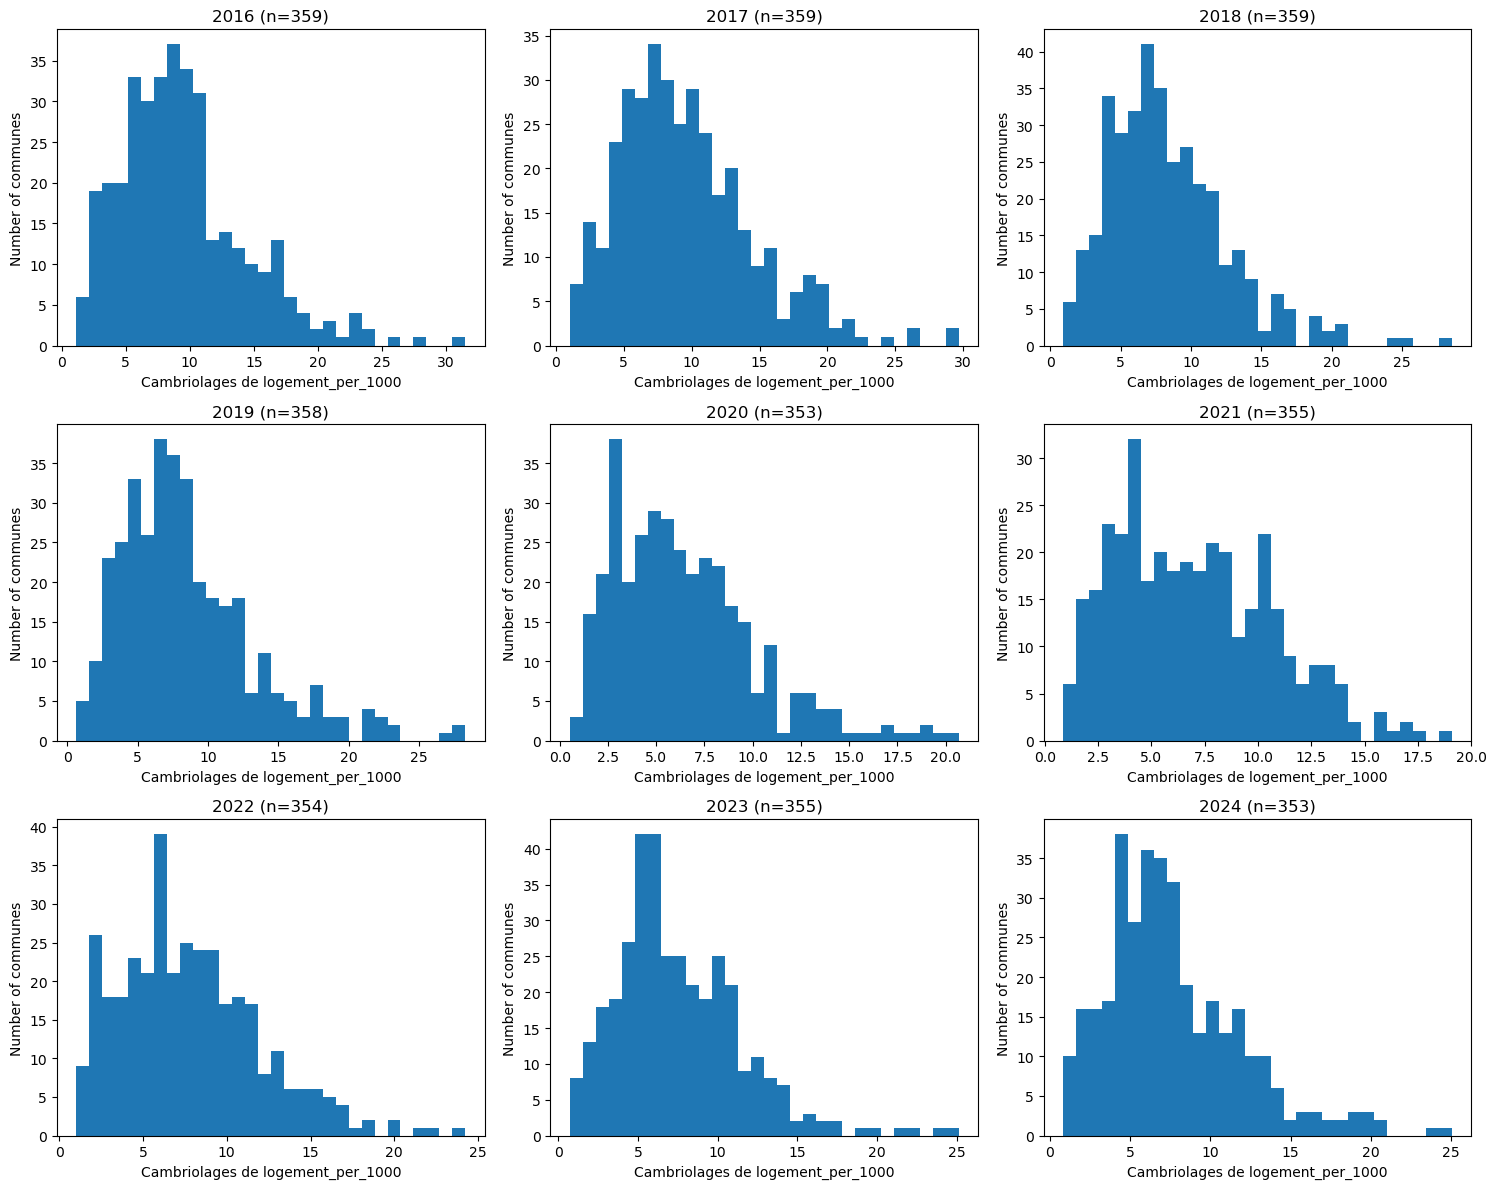

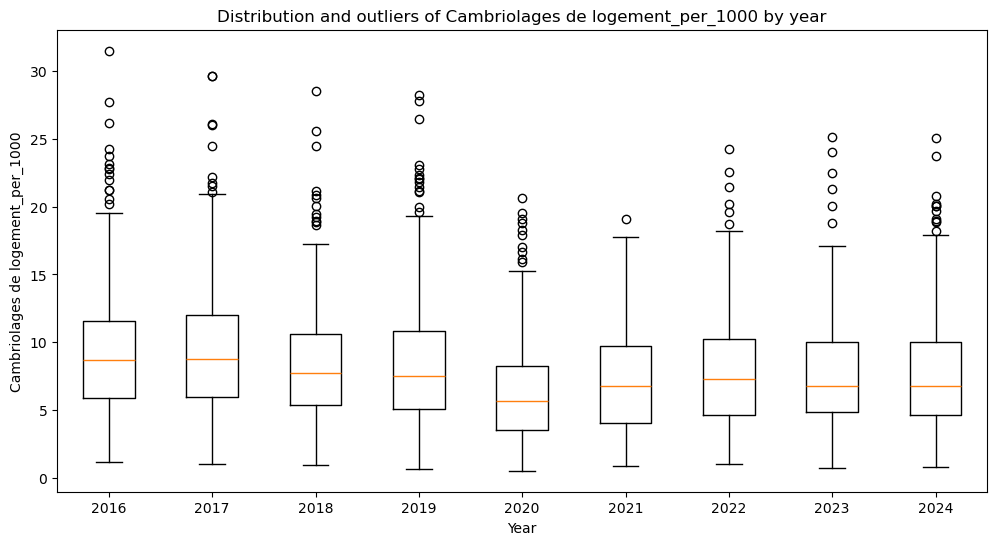


### Destructions et dégradations volontaires_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,362,10.36,9.79,3.60,4.05,24.48
2017,362,10.48,10.09,3.63,3.95,29.72
2018,362,10.26,9.72,3.72,4.38,28.01
2019,362,10.06,9.14,3.54,3.10,21.94
2020,362,8.84,8.50,2.96,3.41,21.94
2021,362,9.17,8.62,3.06,3.03,23.71
2022,362,9.22,8.70,3.20,2.83,19.95
2023,362,9.19,8.88,3.11,2.55,25.10
2024,362,9.00,8.71,3.01,3.14,24.82


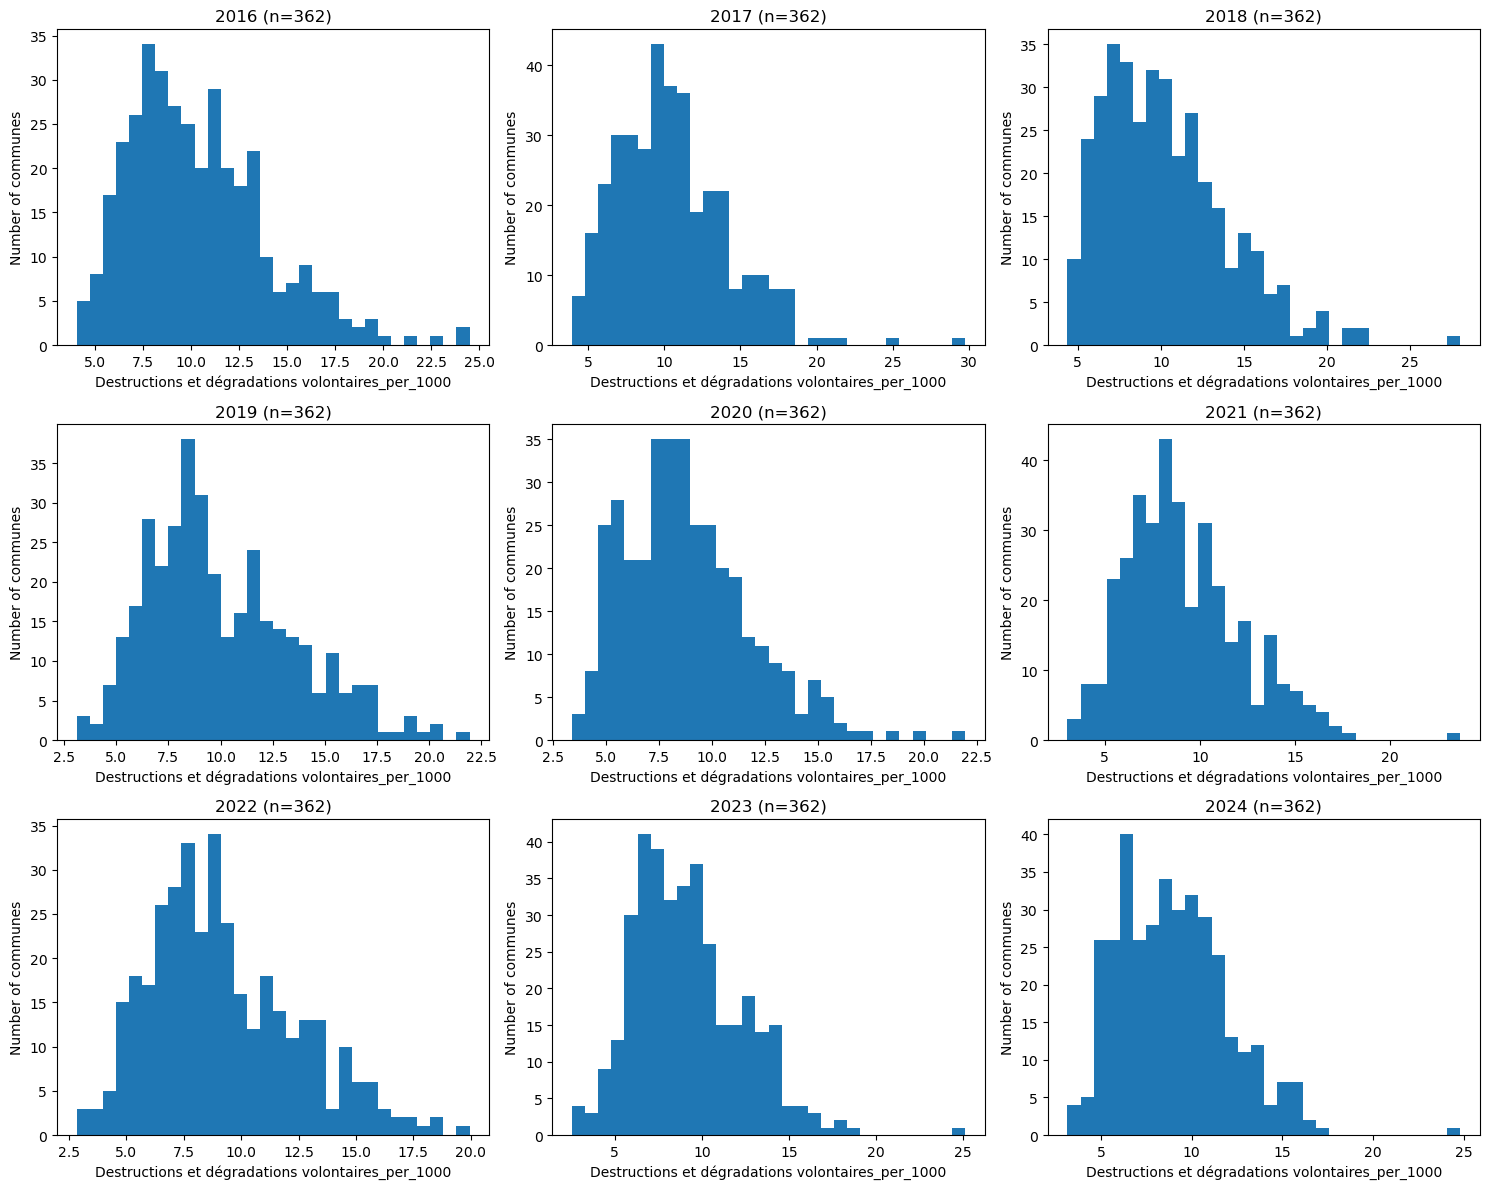

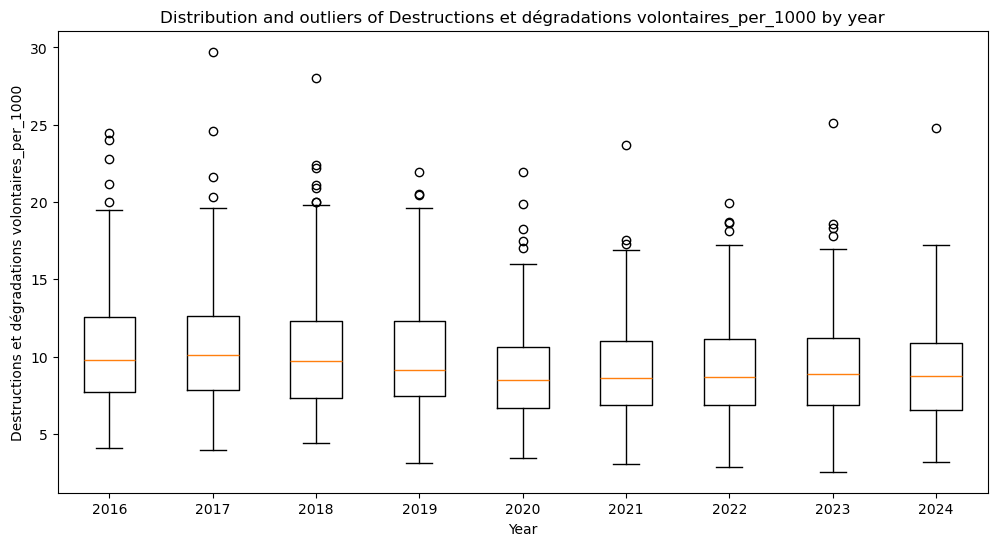


### Escroqueries et fraudes aux moyens de paiement_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,362,3.58,3.41,1.40,1.35,16.83
2017,362,3.85,3.65,1.45,0.77,19.36
2018,362,3.77,3.64,1.18,1.26,11.07
2019,362,4.36,4.30,1.23,1.41,10.65
2020,362,4.84,4.74,1.29,2.21,14.17
2021,362,5.73,5.56,1.26,3.16,10.90
2022,362,6.18,5.96,1.47,2.64,14.03
2023,362,6.46,6.27,1.49,3.30,11.99
2024,362,6.73,6.67,1.55,3.13,12.73


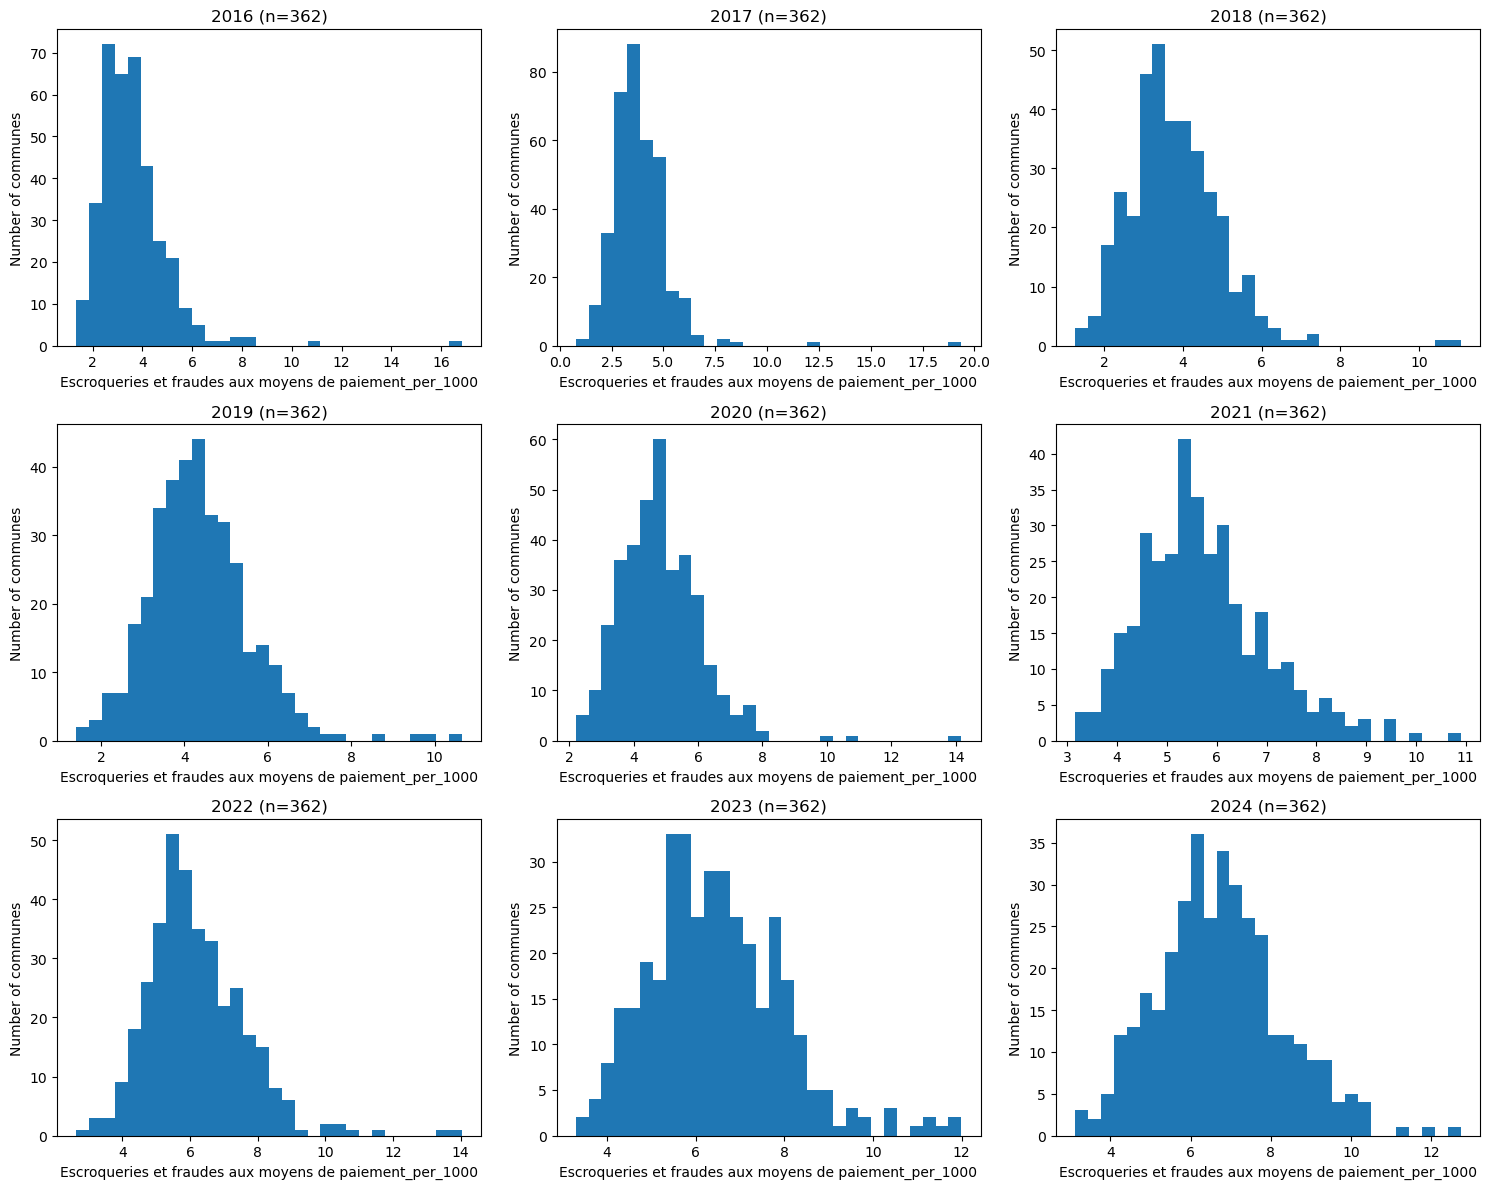

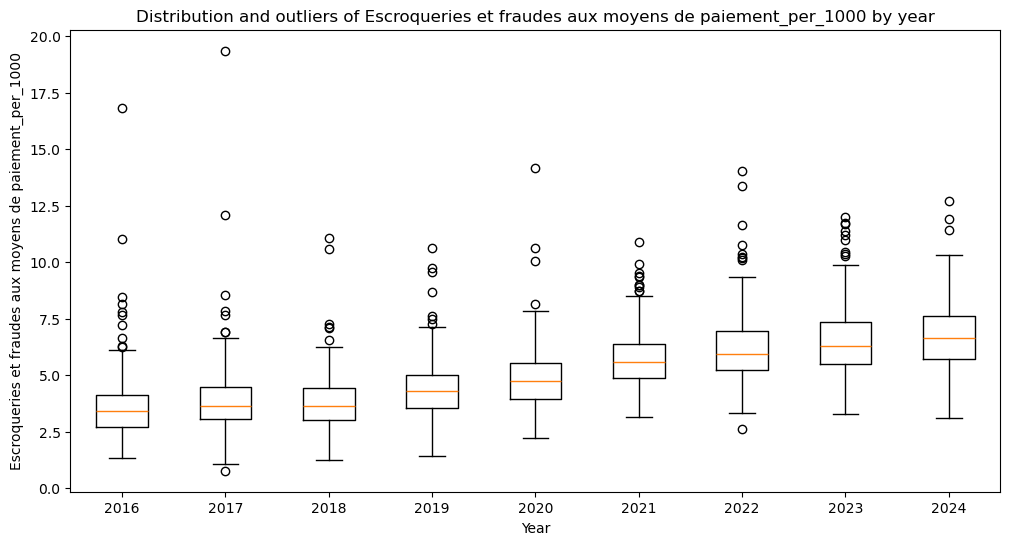


### Usage de stupéfiants_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,313,3.45,2.58,3.29,0.41,37.38
2017,313,3.64,2.80,2.87,0.42,28.18
2018,313,3.69,2.88,3.12,0.38,34.36
2019,308,3.49,2.71,3.02,0.34,27.57
2020,311,3.53,2.87,3.01,0.37,34.56
2021,311,4.39,3.55,3.96,0.29,43.40
2022,325,4.80,3.64,4.61,0.28,41.90
2023,334,5.08,4.04,4.53,0.28,47.59
2024,335,5.63,4.47,5.66,0.33,60.99


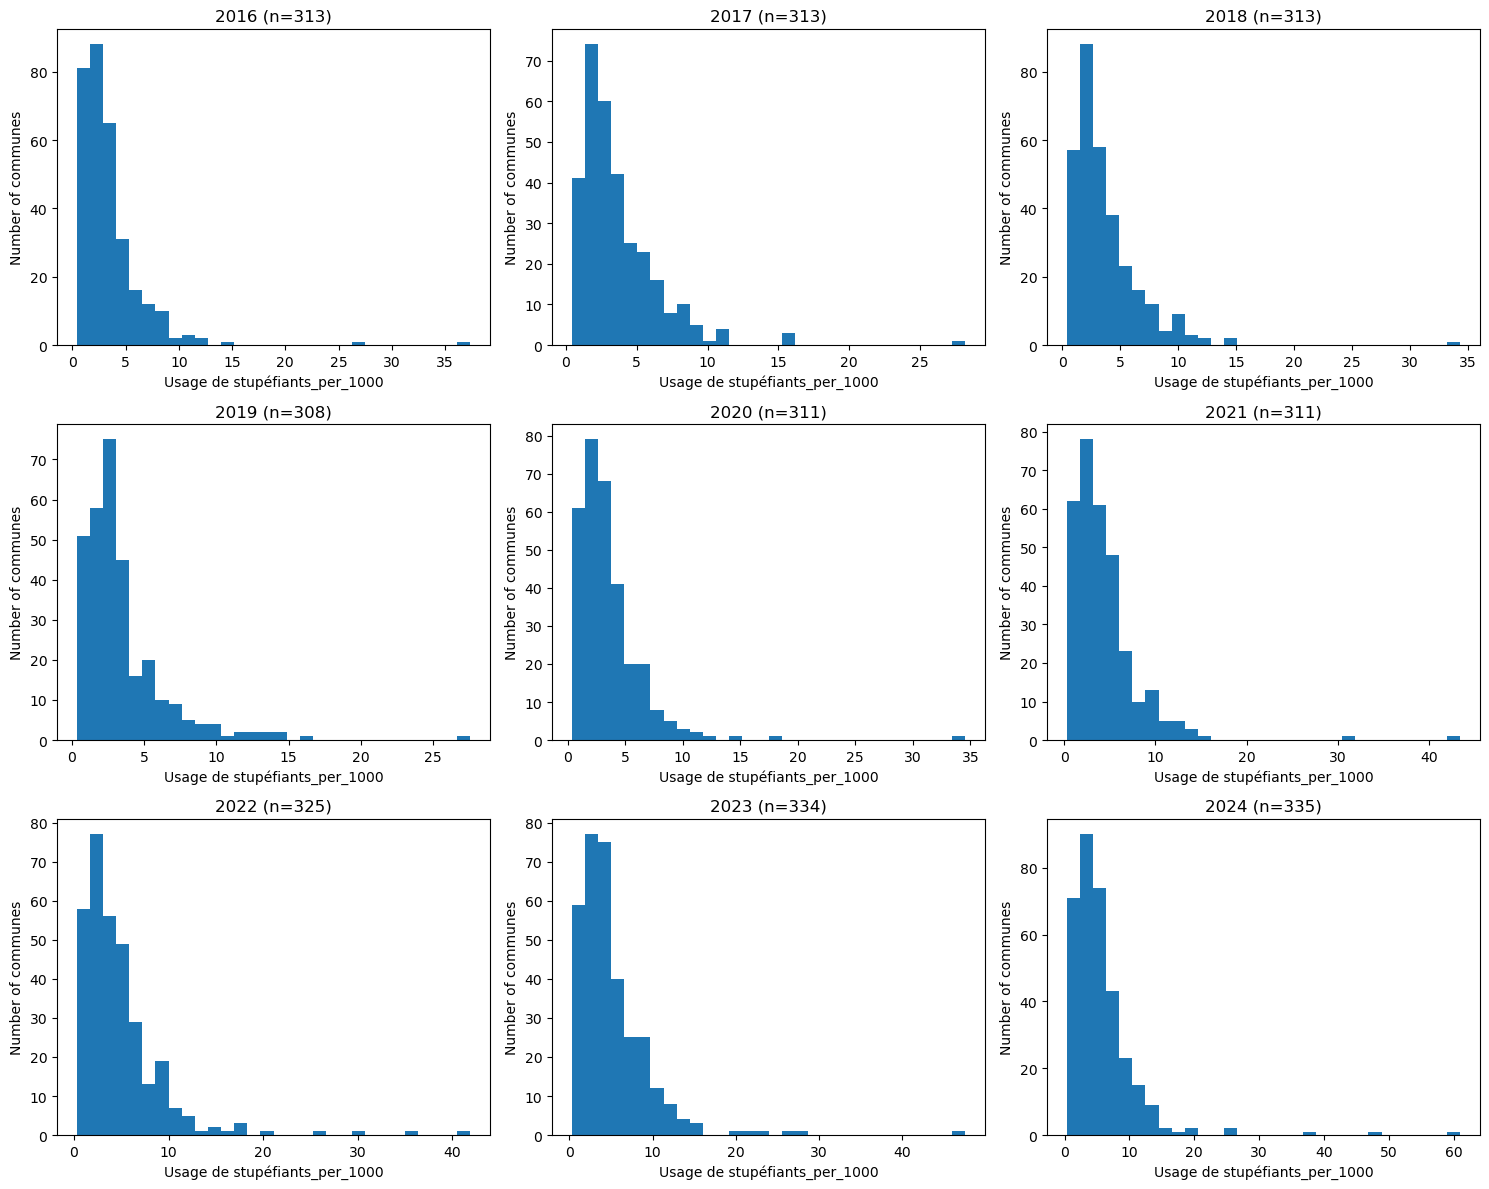

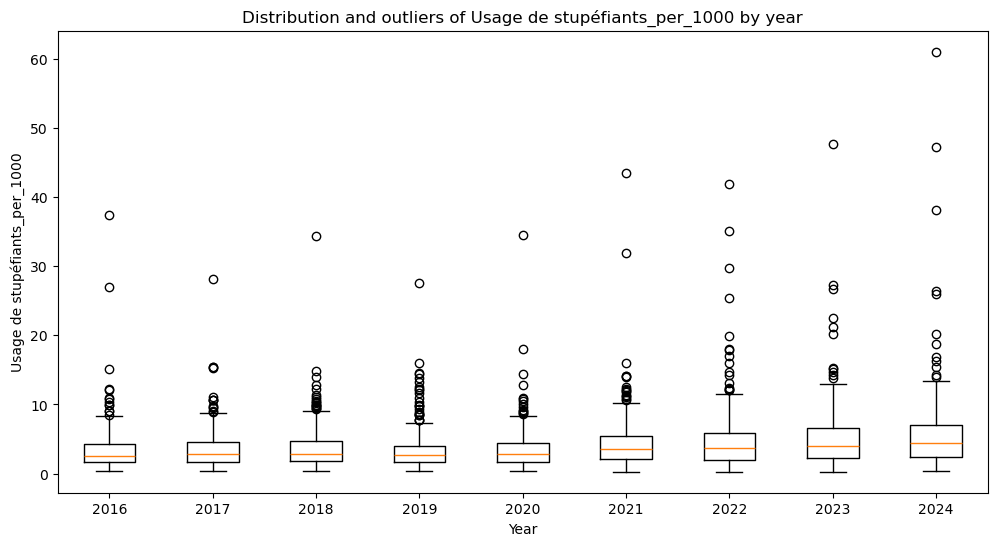


### Violences physiques hors cadre familial_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,329,2.57,2.43,1.35,0.47,10.47
2017,329,2.74,2.55,1.42,0.61,9.01
2018,329,2.98,2.77,1.59,0.39,12.92
2019,339,2.91,2.67,1.50,0.67,9.80
2020,341,2.71,2.43,1.42,0.56,11.85
2021,338,3.04,2.88,1.56,0.50,10.06
2022,336,3.17,2.97,1.67,0.65,12.83
2023,344,3.27,2.91,1.73,0.78,12.55
2024,347,3.34,2.99,1.80,0.69,13.39


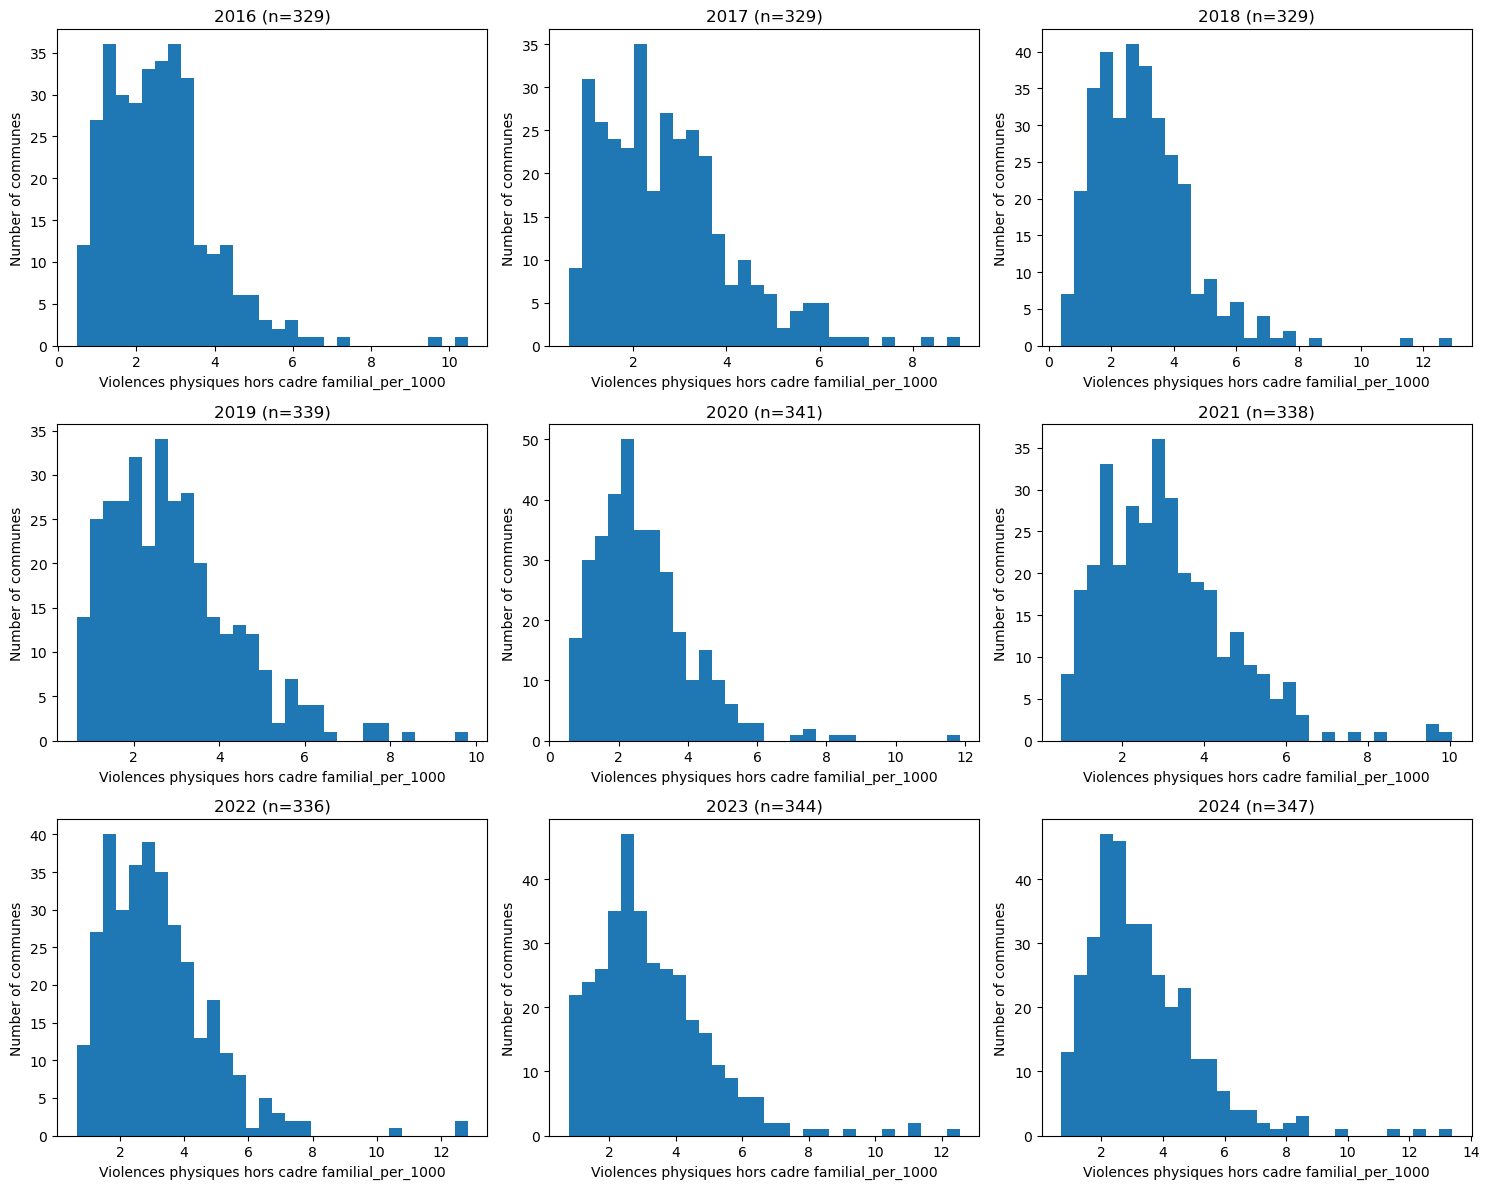

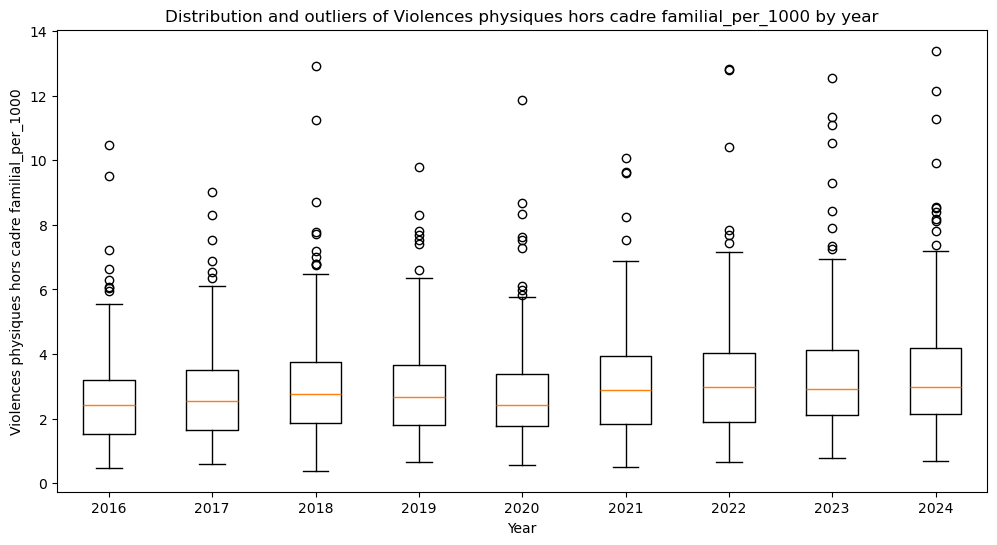


### Violences physiques intrafamiliales_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,311,1.72,1.67,0.70,0.44,3.89
2017,311,1.79,1.73,0.71,0.52,4.20
2018,311,1.91,1.89,0.76,0.29,4.39
2019,328,2.24,2.14,0.87,0.53,6.41
2020,337,2.45,2.39,0.94,0.55,5.84
2021,350,2.66,2.44,1.03,0.70,6.77
2022,349,3.07,3.00,1.12,0.92,8.50
2023,353,3.36,3.28,1.19,0.92,7.25
2024,358,3.38,3.22,1.30,0.59,8.92


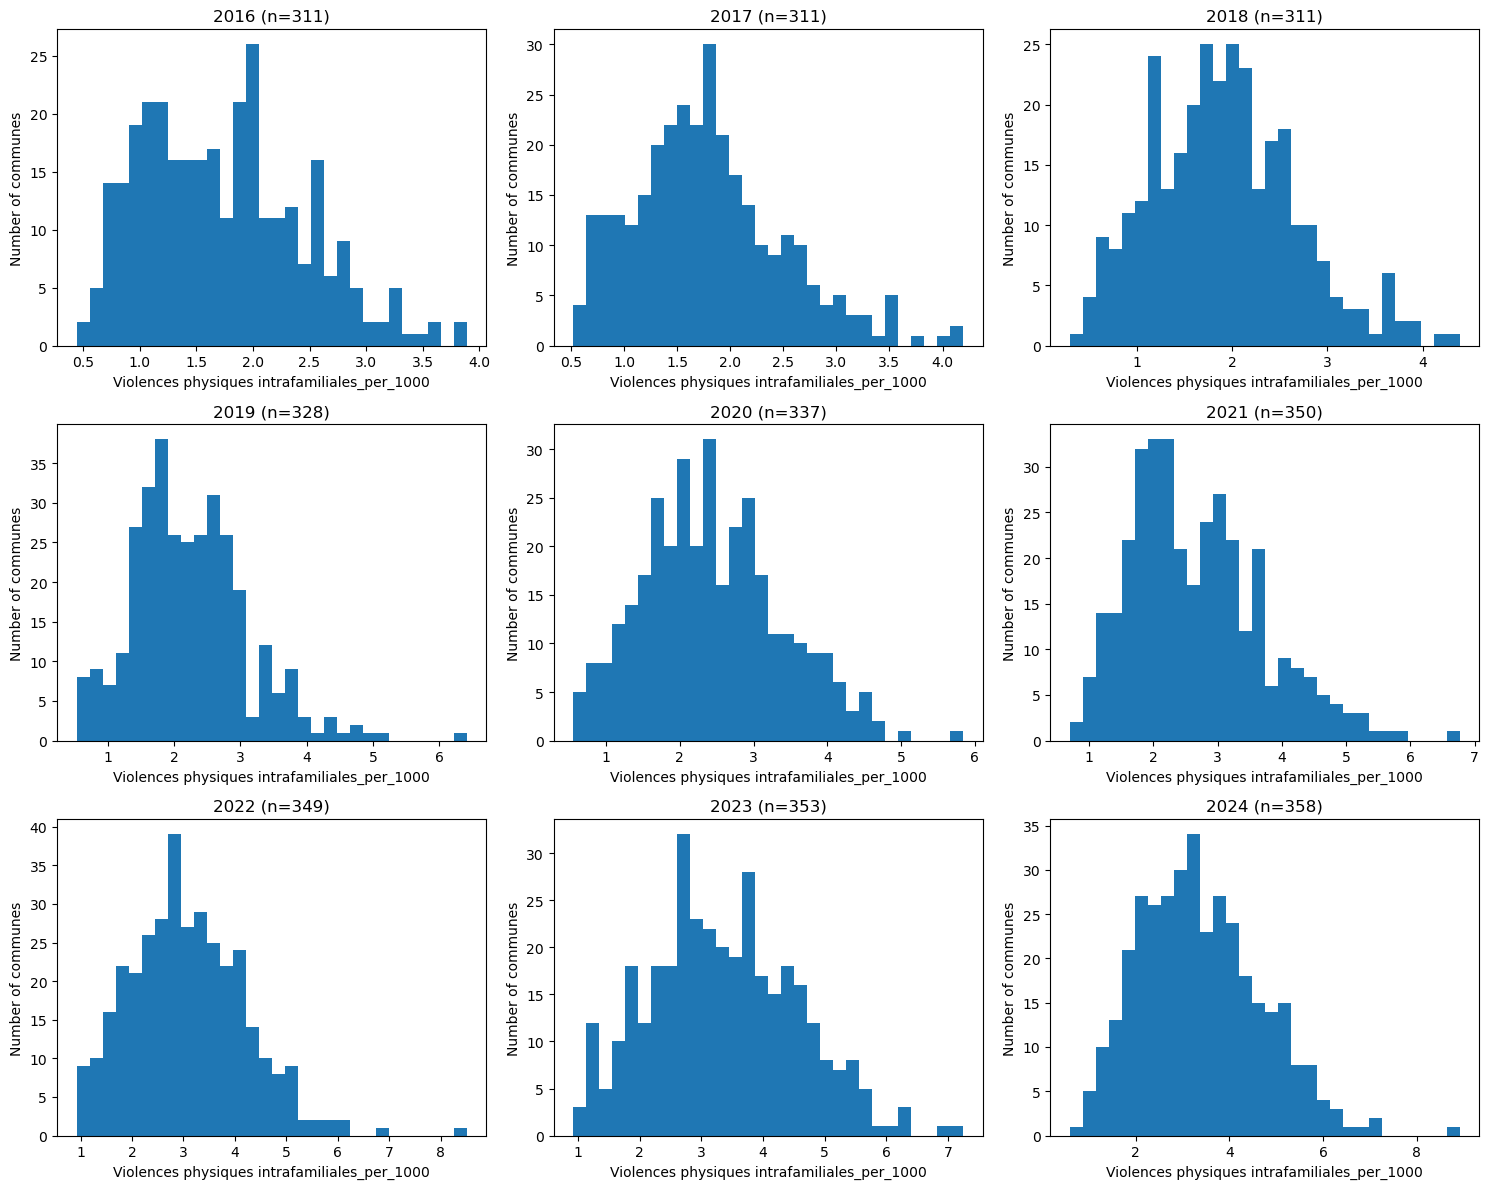

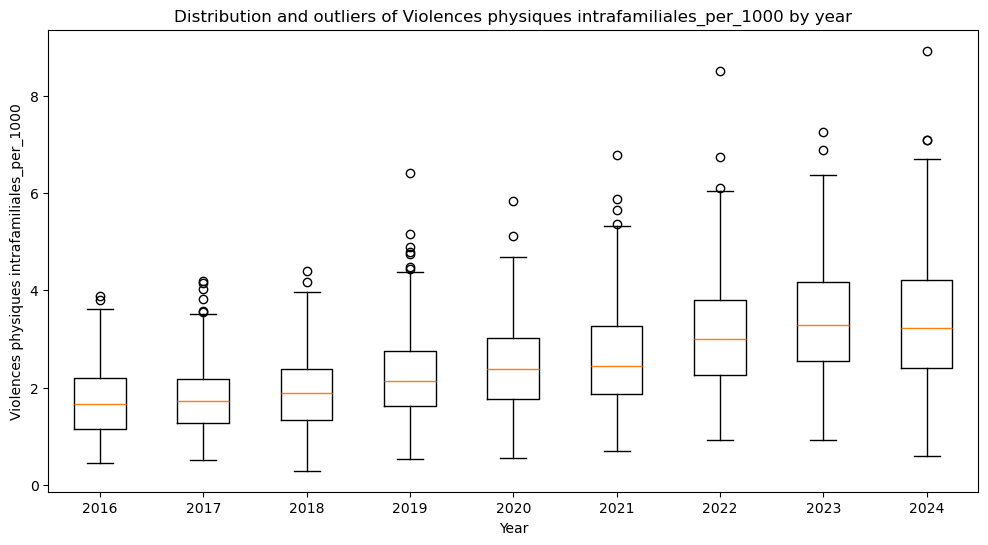


### Vols dans les véhicules_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,352,4.58,3.87,2.94,0.78,21.05
2017,352,4.15,3.39,3.03,0.44,21.65
2018,352,4.17,3.22,3.77,0.62,46.75
2019,349,4.29,3.26,3.58,0.53,25.84
2020,339,3.30,2.55,2.59,0.49,23.63
2021,333,3.48,2.60,3.06,0.46,20.71
2022,330,3.73,2.78,3.32,0.40,22.96
2023,333,3.91,2.91,3.27,0.53,24.13
2024,342,4.09,3.16,3.18,0.45,27.65


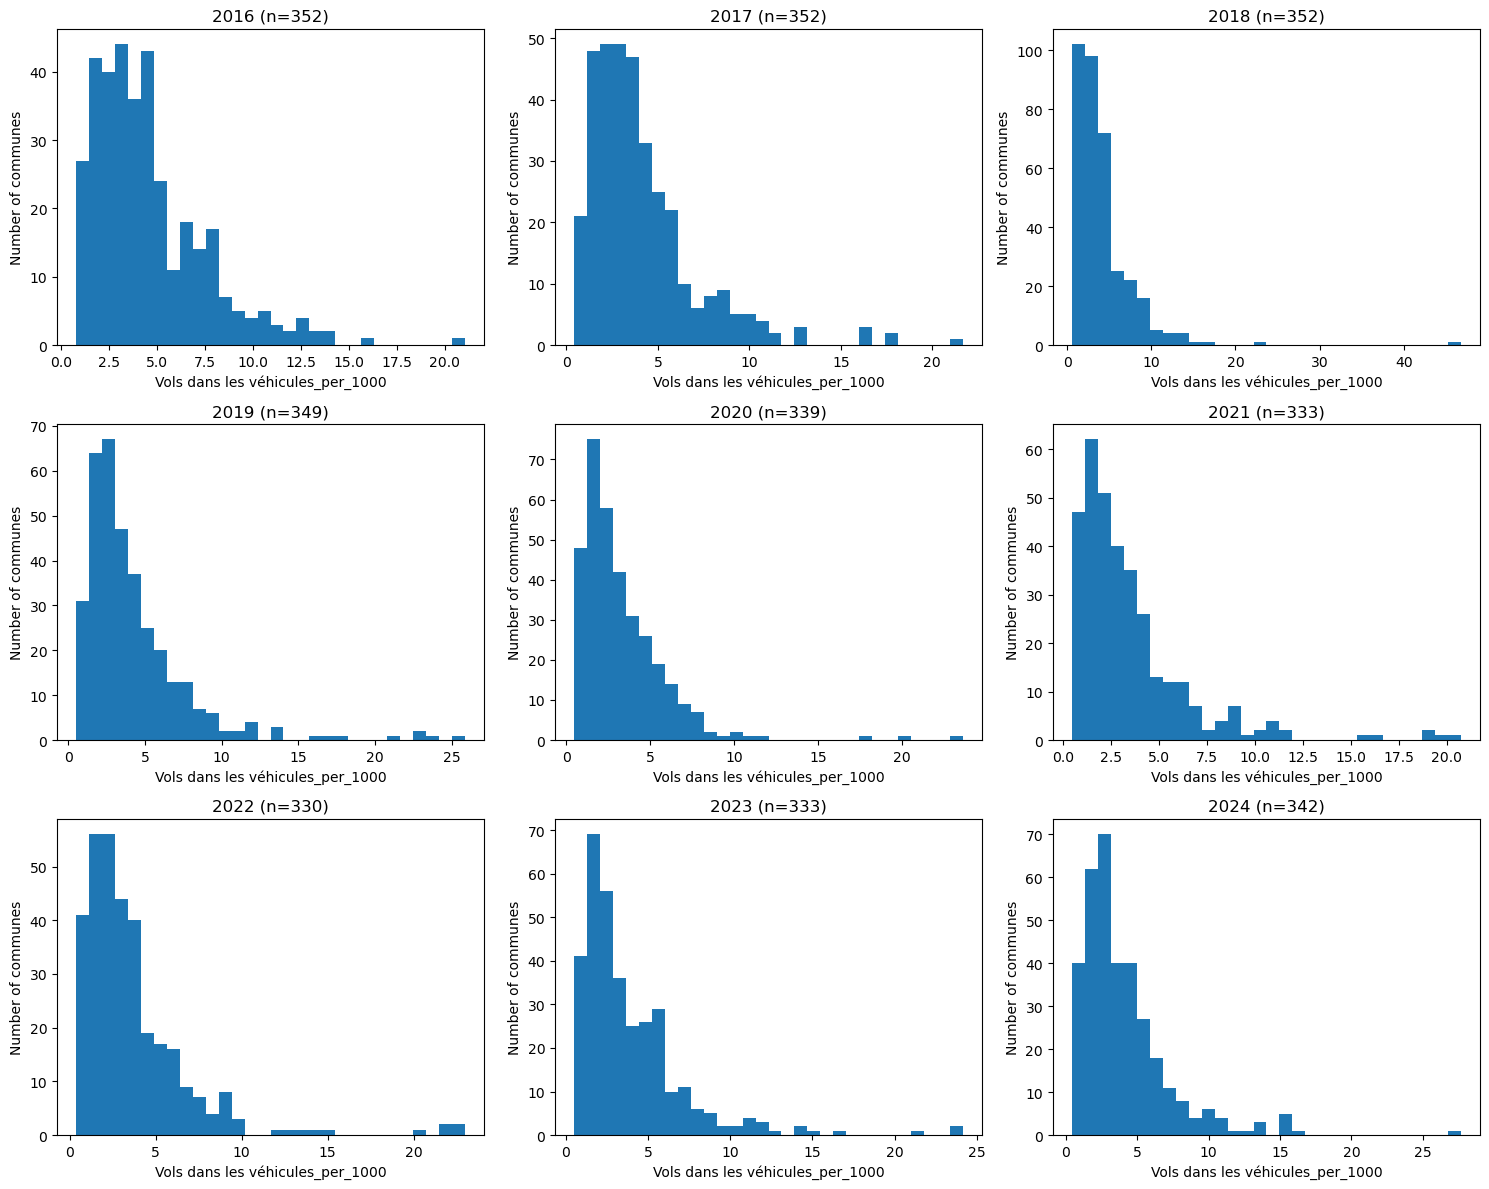

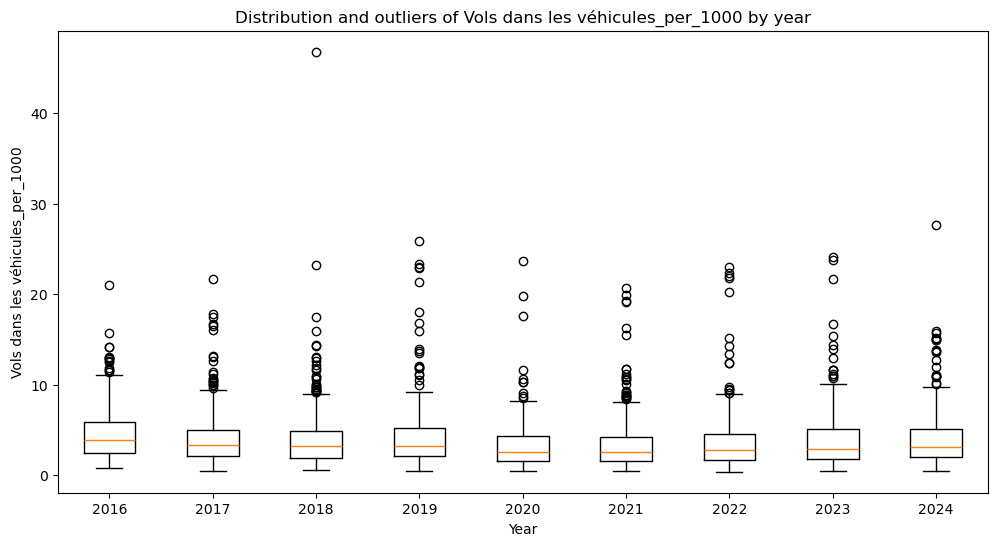


### Vols de véhicule_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,342,3.03,2.77,1.53,0.51,10.47
2017,342,2.74,2.40,1.46,0.57,9.88
2018,342,2.45,2.13,1.38,0.54,9.50
2019,335,2.51,2.29,1.22,0.53,7.79
2020,326,2.10,1.90,1.12,0.45,8.06
2021,320,2.11,1.89,1.15,0.00,8.38
2022,318,2.40,2.17,1.21,0.60,7.81
2023,323,2.57,2.24,1.44,0.39,10.88
2024,334,2.57,2.35,1.33,0.39,7.44


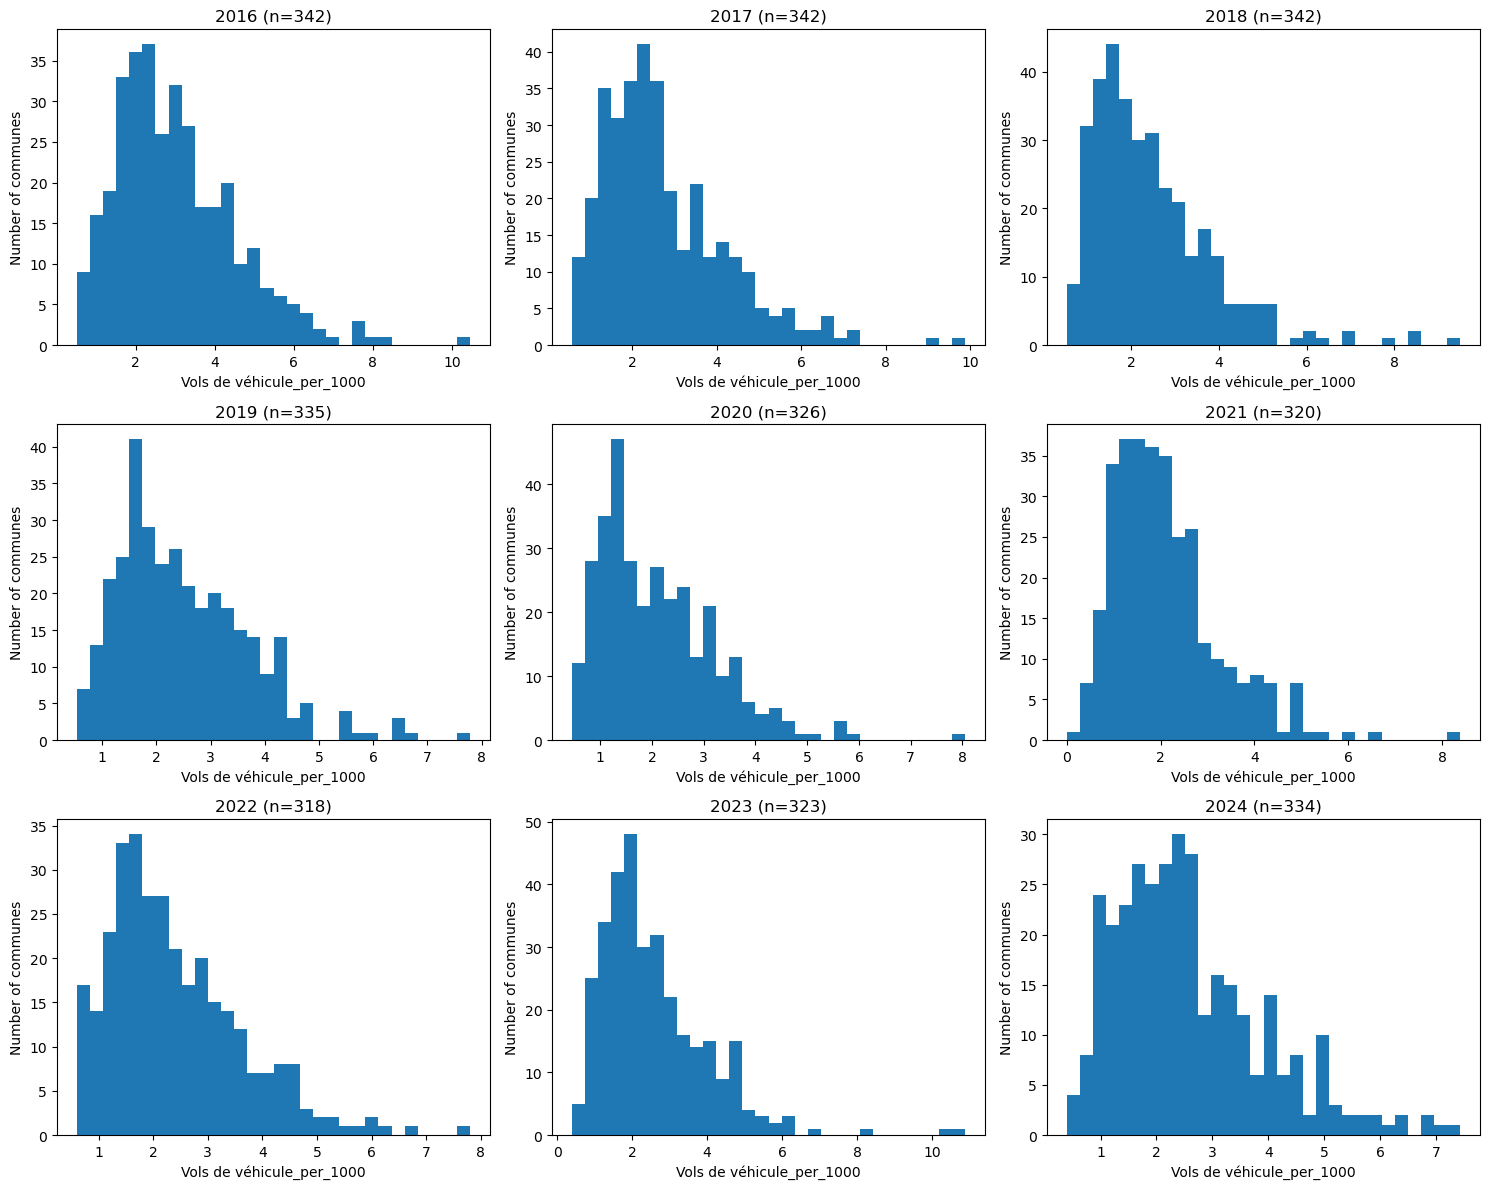

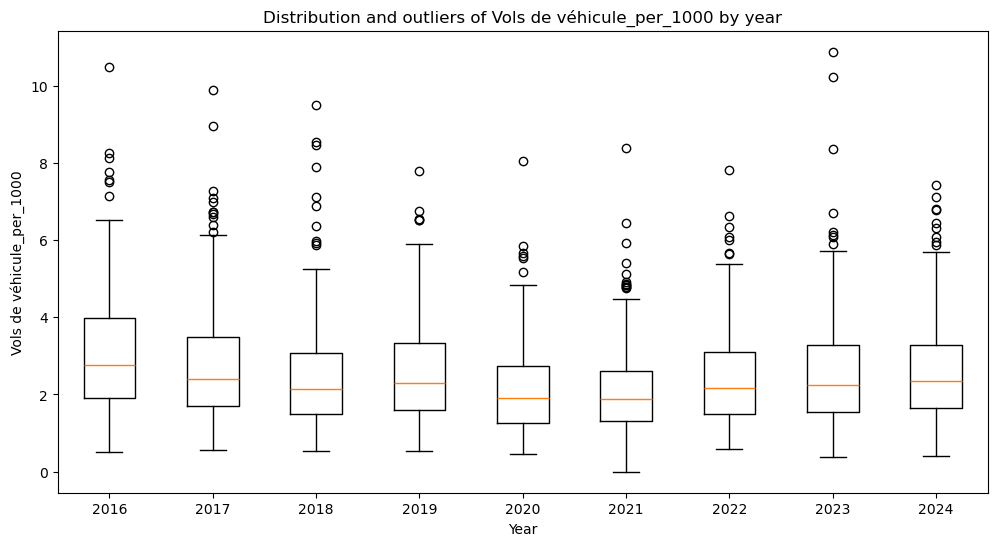


### Vols sans violence contre des personnes_per_1000


,count,mean,median,std,min,max
annee,,,,,,
2016,362,9.19,7.76,6.50,1.09,81.41
2017,362,8.91,7.48,6.59,1.68,92.60
2018,362,8.44,7.31,5.89,1.60,75.80
2019,362,8.29,6.96,6.03,0.96,78.94
2020,362,6.80,5.73,4.72,1.16,61.39
2021,362,7.55,6.53,5.27,1.00,79.09
2022,362,8.40,7.21,6.36,1.32,91.75
2023,361,8.11,6.81,6.07,1.14,87.84
2024,361,7.84,6.61,5.39,1.65,64.42


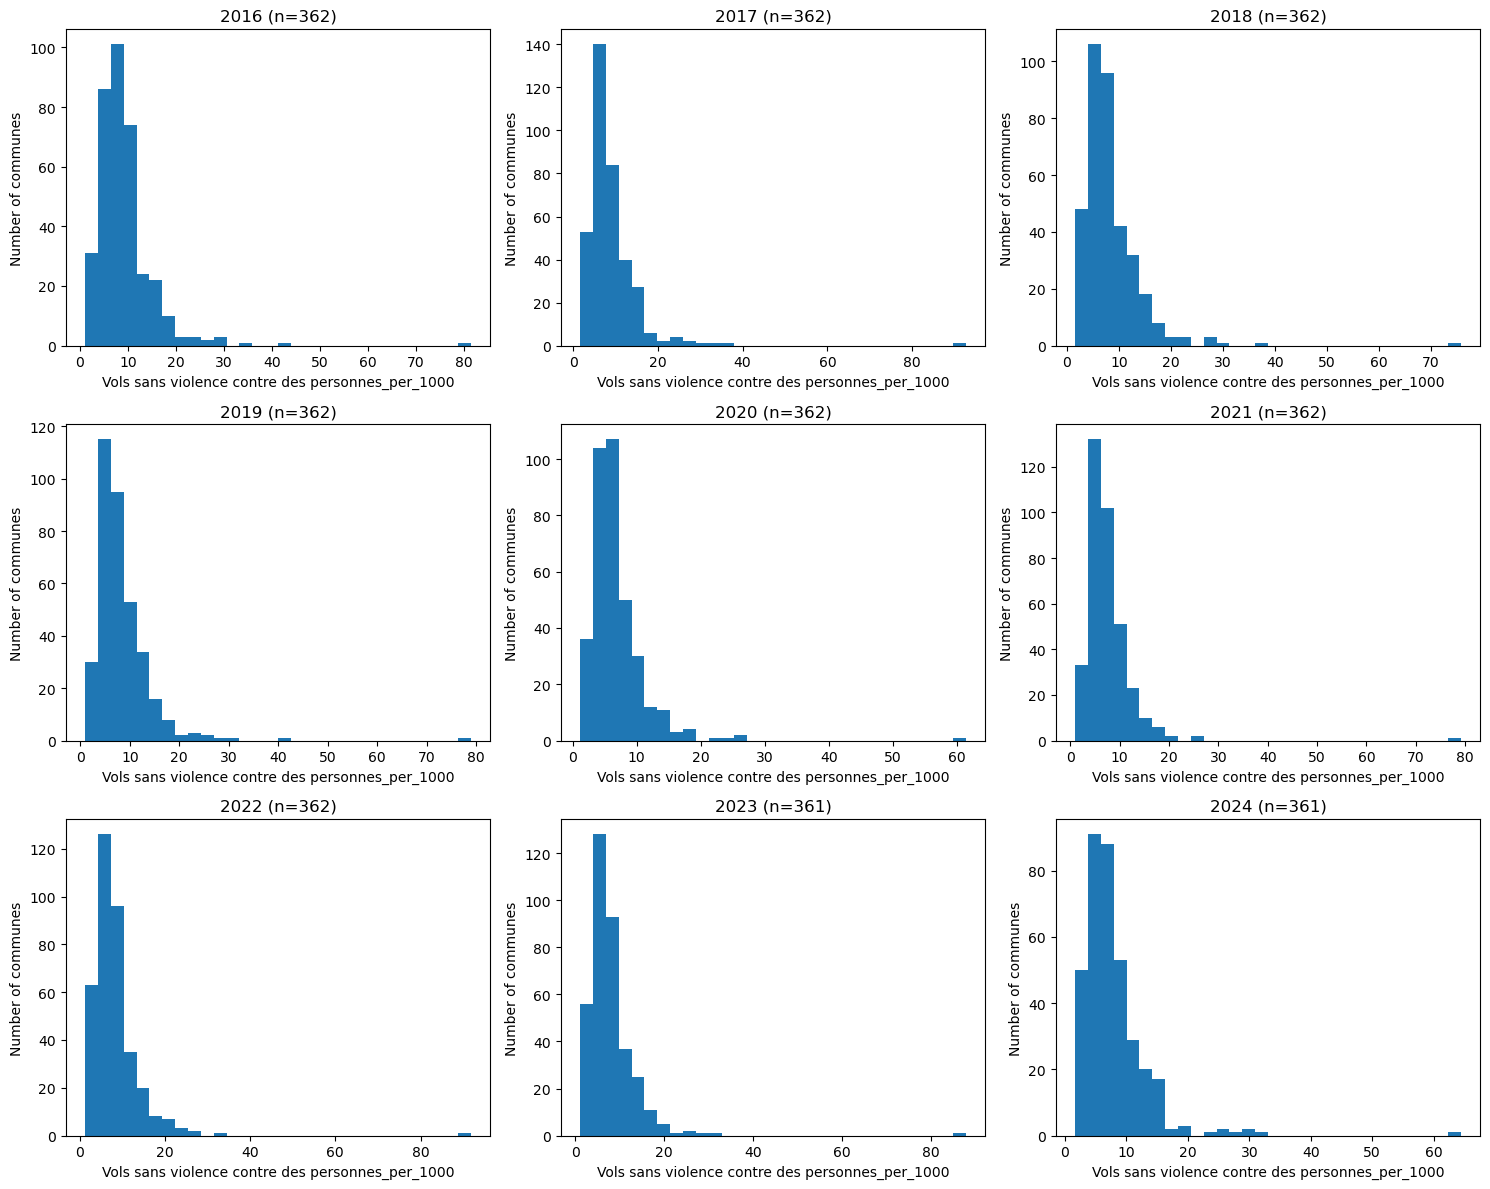

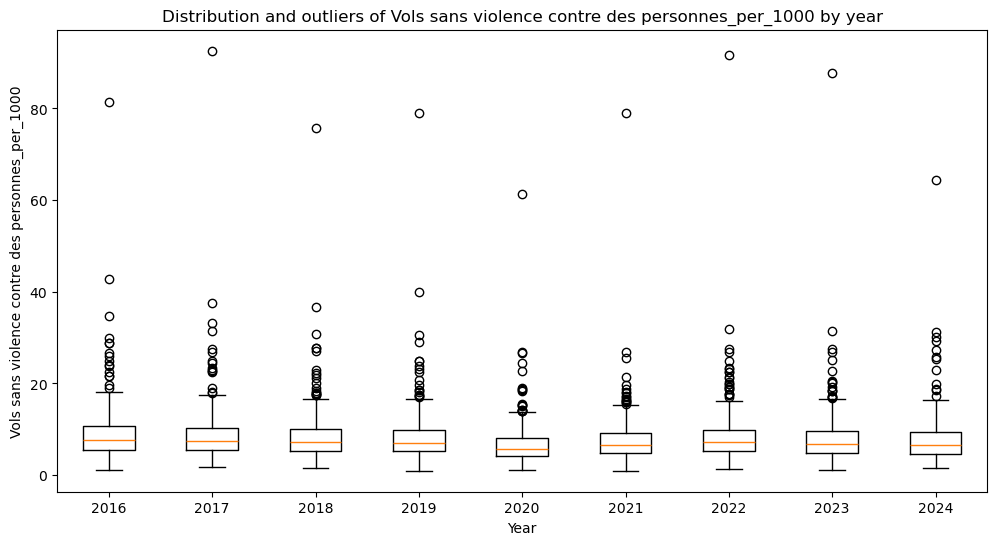

In [376]:
for var in crime_rate_cols_core:
    print(f"\n### {var}")
    display(summary_by_year(crime_wide, var).round(2))
    plot_histograms_by_year(crime_wide, var)
    plot_boxplot_by_year(crime_wide, var)

In [377]:
# OBSERVATIONS
# Several patterns emerge from these yearly distributions and boxplots.
#
# 1. Most crime indicators are strongly right-skewed:
# many communes are concentrated at relatively low levels, while a smaller number of communes form a long upper tail.
# This points to persistent territorial concentration rather than evenly spread crime intensity.
#
# 2. Outliers are present every year across almost all indicators.
# This suggests that a limited number of communes consistently stand far above the rest,
# especially for burglary, theft-related indicators, drug use, and non-violent theft against persons.
#
# 3. A visible break appears around 2020 for several property-related crime indicators.
# Burglary, vehicle theft, theft from vehicles, and voluntary destruction/degradation all show a downward shift around 2020.
# This pattern may plausibly be linked to the COVID period and lockdown measures, although this remains an interpretation rather than a direct result shown by the dataset itself.
# A partial rebound is observed afterwards, with recent values in several cases moving back close to their pre-COVID levels.
#
# 4. By contrast, some indicators display a clear upward structural trend over the whole period.
# This is especially visible for payment fraud, drug use, physical violence outside the family, and even more strongly for intrafamilial physical violence.
#
# 5. Intrafamilial physical violence stands out as one of the clearest upward-moving indicators:
# the whole distribution shifts upward over time, not just a few extreme cases. This suggests a broad rise across communes rather than an outlier-driven pattern.
#
# 6. Payment fraud also shows a marked and steady rightward shift from 2016 to 2024.
# Here again, the increase affects the central part of the distribution, which makes the upward trend appear more structural than anecdotal.
#
# 7. Drug-use rates remain highly unequal across communes.
# The distribution stays very asymmetric, and the upper tail becomes more pronounced over time, indicating increasingly strong gaps between ordinary and high-intensity communes.
#
# 8. Non-violent theft against persons remains one of the most extreme indicators in the dataset.
# Its distribution is heavily concentrated at low levels for most communes, but a few communes reach exceptionally high values,
# suggesting a very strong concentration of this crime type in specific places.
#
# 9. Overall, the boxplots confirm that temporal changes do not affect all crime types in the same way:
# some distributions shift downward, some rebound after 2020, and others move steadily upward across the whole period.

# This supports a differentiated reading of crime dynamics rather than a single general trend.

In [378]:
# FURTHER ANALYSIS
# The following step goes beyond descriptive EDA.
# It is a first attempt at a more advanced comparative analysis, aimed at identifying the commune-year observations that stand out most strongly
# across the core crime indicators taken together.
# To do so, crime rates are standardized within each year, and then combined into a global composite score.

In [379]:
# TOP extreme communes

In [380]:
def top_communes_by_year(df, variable, top_n=10):
    return (
        df[["insee_commune_id", "annee", variable]]
        .dropna()
        .sort_values(["annee", variable], ascending=[True, False])
        .groupby("annee")
        .head(top_n)
    )

In [381]:
for var in crime_rate_cols_core:
    print(f"\n### Top 10 communes by year — {var}")
    display(top_communes_by_year(crime_wide, var, top_n=10).round(2))


### Top 10 communes by year — Cambriolages de logement_per_1000


,insee_commune_id,annee,Cambriolages de logement_per_1000
2115,69072,2016,31.51
2358,69279,2016,27.75
2223,69194,2016,26.20
2214,69191,2016,24.25
2313,69271,2016,23.72
...,...,...,...
2735,74305,2024,20.04
2366,69279,2024,19.65
1763,42223,2024,19.10
1322,38179,2024,18.92



### Top 10 communes by year — Destructions et dégradations volontaires_per_1000


,insee_commune_id,annee,Destructions et dégradations volontaires_per_1000
2871,83070,2016,24.48
1683,42183,2016,23.98
2988,83119,2016,22.80
531,06159,2016,21.18
1629,42044,2016,20.02
...,...,...,...
287,05023,2024,15.91
719,13022,2024,15.81
1376,38298,2024,15.79
2447,73054,2024,15.77



### Top 10 communes by year — Escroqueries et fraudes aux moyens de paiement_per_1000


...

,insee_commune_id,annee,Vols dans les véhicules_per_1000
837,13051,2016,21.05
1476,38449,2016,15.74
2988,83119,2016,14.19
1197,26252,2016,14.17
999,13104,2016,13.01
...,...,...,...
701,13019,2024,14.99
1304,38158,2024,14.96
2096,69040,2024,13.88
1295,38151,2024,13.68



### Top 10 communes by year — Vols de véhicule_per_1000


,insee_commune_id,annee,Vols de véhicule_per_1000
2988,83119,2016,10.47
1071,13117,2016,8.26
1017,13106,2016,8.11
774,13039,2016,7.75
909,13077,2016,7.55
...,...,...,...
1484,38449,2024,6.31
1709,42186,2024,6.08
1979,63164,2024,5.94
2735,74305,2024,5.87



### Top 10 communes by year — Vols sans violence contre des personnes_per_1000


,insee_commune_id,annee,Vols sans violence contre des personnes_per_1000
2988,83119,2016,81.41
2547,74056,2016,42.81
342,06029,2016,34.75
2439,73054,2016,30.01
441,06088,2016,28.82
...,...,...,...
1331,38185,2024,25.71
2537,74012,2024,25.32
2879,83070,2024,23.01
3086,84007,2024,19.89


In [382]:
# TOP 10 communes across all core crime indicators using a standardized score

In [383]:
crime_core_scores = crime_wide[["insee_commune_id", "annee"] + crime_rate_cols_core].copy()

# Standardize each crime variable within each year
for var in crime_rate_cols_core:
    crime_core_scores[f"{var}_z"] = (
        crime_core_scores
        .groupby("annee")[var]
        .transform(lambda x: (x - x.mean()) / x.std())
    )

z_cols = [f"{var}_z" for var in crime_rate_cols_core]

# Global crime intensity score = mean z-score across core crime types
crime_core_scores["core_crime_score"] = crime_core_scores[z_cols].mean(axis=1, skipna=True)

top10_core_global = (
    crime_core_scores[["insee_commune_id", "annee", "core_crime_score"]]
    .dropna()
    .sort_values("core_crime_score", ascending=False)
    .head(10)
)

top10_core_global.round(2)

,insee_commune_id,annee,core_crime_score
2995,83119,2023,4.58
2988,83119,2016,4.20
2992,83119,2020,4.02
2994,83119,2022,4.01
2993,83119,2021,3.88
2996,83119,2024,3.83
2991,83119,2019,3.51
2990,83119,2018,3.42
2989,83119,2017,3.35
1523,38516,2018,2.64


In [384]:
top10_core_global_named = (
    top10_core_global
    .merge(
        insee_to_commune_subset[["insee_commune_id", "commune_name"]].drop_duplicates(),
        on="insee_commune_id",
        how="left"
    )
    [["annee", "insee_commune_id", "commune_name", "core_crime_score"]]
    .sort_values("core_crime_score", ascending=False)
)

top10_core_global_named.round(2)

,annee,insee_commune_id,commune_name,core_crime_score
0,2023,83119,Saint-Tropez,4.58
1,2016,83119,Saint-Tropez,4.20
2,2020,83119,Saint-Tropez,4.02
3,2022,83119,Saint-Tropez,4.01
4,2021,83119,Saint-Tropez,3.88
5,2024,83119,Saint-Tropez,3.83
6,2019,83119,Saint-Tropez,3.51
7,2018,83119,Saint-Tropez,3.42
8,2017,83119,Saint-Tropez,3.35
9,2018,38516,Tronche,2.64


In [385]:
# TOP 10 communes across all core crime indicators ans accross all years using a standardized score

In [386]:
top10_communes_all_years = (
    crime_core_scores
    .groupby("insee_commune_id", as_index=False)["core_crime_score"]
    .mean()
    .merge(
        insee_to_commune_subset[["insee_commune_id", "commune_name"]].drop_duplicates(),
        on="insee_commune_id",
        how="left"
    )
    [["insee_commune_id", "commune_name", "core_crime_score"]]
    .sort_values("core_crime_score", ascending=False)
    .head(10)
)

top10_communes_all_years.round(2)

,insee_commune_id,commune_name,core_crime_score
332,83119,Saint-Tropez,3.87
164,38449,Saint-Quentin-Fallavier,2.05
169,38516,Tronche,1.76
147,38185,Grenoble,1.67
79,13022,Cassis,1.32
38,06029,Cannes,1.26
254,69259,Vénissieux,1.26
342,84007,Avignon,1.19
152,38298,Péage-de-Roussillon,1.10
143,38151,Échirolles,1.09


In [387]:
# IMPORTANT NOTE
# This analysis should not be interpreted as representative of crime patterns in France as a whole.
# At this stage, the dataset is restricted to communes located in the vicinity of two major metropolitan areas:
# Lyon and Marseille.
# The results should therefore be read as a localized exploratory analysis, shaped by the specific territorial context of these two urban regions.

In [388]:
# ============================================================
# B.4 — air_pollution_subset
# ============================================================

In [389]:
# ---------------------------------------
# a — dataset structure
# ---------------------------------------

In [ ]:
# ---------------------------------------
# b — descriptive statistics
# ---------------------------------------

In [ ]:
# ---------------------------------------
# c — distribution
# ---------------------------------------

In [15]:
# ---------------------------------------
# d — outliers
# ---------------------------------------

In [390]:
# =========================================================================
# II — Aggregation at commune level
# =========================================================================
# This section aggregates the datasets prepared in N3 at commune level in order to:
# - harmonize variables across datasets with different granularities
# - create one analytical observation per commune
# - prepare a unified commune-level table for further comparison and analysis

In [391]:
# ============================================================
# disposable_income_subset
# ============================================================
# aggregation méthodology column by column:
# ------------------------------------------------------------
# Group A - Identifiers and context
# ------------------------------------------------------------
# insee_commune_id  = groupby key
# iris_id           = count number of IRIS per commune ==> n_iris
# commune_name      = keep first one per commune
# place_in_commune  = to be excluded
# ------------------------------------------------------------
# Group B - Levels of incomes
# ------------------------------------------------------------
# revenu_q1_eur -> median
# revenu_median_eur -> median
# revenu_q3_eur -> median
# revenu_d1_eur -> median
# revenu_d9_eur -> median
# median = less sensible to extreme values - nearer to typical income profile for each commune
# ------------------------------------------------------------
# Group C - Vulnerability measurements
# ------------------------------------------------------------
# taux_bas_revenus_pct -> mean
# part_revenus_activite_pct -> mean
# part_pensions_pct -> mean
# part_revenus_patrimoine_pct -> mean
# part_prestations_sociales_pct -> mean
# part_prestations_familiales_pct -> mean
# part_minima_sociaux_pct -> mean
# part_prestations_logement_pct -> mean
# part_impots_pct -> mean
# ------------------------------------------------------------
# Groupe D — intra-communal heterogénéity 
# -------------------------------------------------------------
# supplementary columns so as to not loose important info:
# - revenu_median_eur -> std
# - taux_bas_revenus_pct -> std
# - part_prestations_sociales_pct -> std
# - revenu_median_eur -> IQR = Q3 - Q1 : more robust than standard deviation when we have extreme values.

In [392]:
disposable_income_subset.head()

,insee_commune_id,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,010040101,Ambérieu-en-Bugey,Les Pérouses-Triangle d'Activités,19.0,14990.0,20350.0,26140.0,11620.0,32060.0,70.8,26.9,6.2,8.6,3.3,3.8,1.5,-12.5
1,01004,010040102,Ambérieu-en-Bugey,Longeray-Gare,25.0,13880.0,18570.0,24760.0,10580.0,31130.0,70.6,24.9,5.8,11.1,3.7,5.1,2.3,-12.4
2,01004,010040201,Ambérieu-en-Bugey,Centre-Saint-Germain-Vareilles,19.0,15190.0,20700.0,27180.0,11400.0,34450.0,72.5,27.2,6.4,7.7,2.8,3.3,1.6,-13.8
3,01004,010040202,Ambérieu-en-Bugey,Tiret-Les Allymes,8.0,19600.0,25230.0,33170.0,14810.0,41230.0,73.3,23.8,16.2,4.0,1.8,1.5,0.7,-17.3
4,01033,010330102,Valserhône,Centre Ville,24.0,14050.0,20420.0,29640.0,9410.0,42390.0,78.9,23.7,5.2,5.3,1.5,2.5,1.3,-13.1


In [393]:
# ------------------------------------------------------------
# Group A - Identifiers and context
# ------------------------------------------------------------
# insee_commune_id  = groupby key
# iris_id           = count number of IRIS per commune ==> n_iris
# commune_name      = keep first one per commune
# place_in_commune  = to be excluded

In [394]:
# ============================================================
# Group A - identifiers and context
# ============================================================
# check if one commune_id corresponds to only one commune_name
name_check = (
    disposable_income_subset
    .groupby("insee_commune_id")["commune_name"]
    .nunique()
)

print("Communes with more than one commune_name:", (name_check > 1).sum())

group_a_commune = (
    disposable_income_subset
    .groupby("insee_commune_id", as_index=False)
    .agg(
        n_iris=("iris_id", "nunique"),      # number of IRIS per commune
        commune_name=("commune_name", "first")
    )
)

group_a_commune.head()

Communes with more than one commune_name: 0


,insee_commune_id,n_iris,commune_name
0,01004,4,Ambérieu-en-Bugey
1,01033,6,Valserhône
2,01034,3,Belley
3,01053,18,Bourg-en-Bresse
4,01143,3,Divonne-les-Bains


In [395]:
# ============================================================
# Group B - income levels
# ============================================================

group_b_commune = (
    disposable_income_subset
    .groupby("insee_commune_id", as_index=False)
    .agg(
        revenu_q1_eur=("revenu_q1_eur", "median"),
        revenu_median_eur=("revenu_median_eur", "median"),
        revenu_q3_eur=("revenu_q3_eur", "median"),
        revenu_d1_eur=("revenu_d1_eur", "median"),
        revenu_d9_eur=("revenu_d9_eur", "median"),
    )
)

group_b_commune.head()

,insee_commune_id,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur
0,01004,15090.0,20525.0,26660.0,11510.0,33255.0
1,01033,15930.0,23210.0,33820.0,10980.0,46450.0
2,01034,15690.0,20930.0,27660.0,11780.0,36550.0
3,01053,15510.0,21185.0,27945.0,11140.0,36705.0
4,01143,25900.0,45240.0,72960.0,15410.0,107240.0


In [396]:
disposable_income_subset.loc[disposable_income_subset["insee_commune_id"] == "01143"]

,insee_commune_id,iris_id,commune_name,place_in_commune,taux_bas_revenus_pct,revenu_q1_eur,revenu_median_eur,revenu_q3_eur,revenu_d1_eur,revenu_d9_eur,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
31,01143,011430101,Divonne-les-Bains,Centre,9.0,25670.0,43380.0,68210.0,14510.0,100500.0,96.8,18.8,7.0,0.8,0.2,0.4,0.2,-23.4
32,01143,011430102,Divonne-les-Bains,Nord-Ouest,7.0,29600.0,51650.0,79590.0,16960.0,119750.0,99.7,14.3,7.1,0.8,0.3,0.3,0.2,-21.9
33,01143,011430103,Divonne-les-Bains,Sud-Ouest,8.0,25900.0,45240.0,72960.0,15410.0,107240.0,95.6,15.3,10.3,1.1,0.4,0.5,0.2,-22.3


In [397]:
# ============================================================
# Group C - vulnerability measurements
# ============================================================

group_c_commune = (
    disposable_income_subset
    .groupby("insee_commune_id", as_index=False)
    .agg(
        taux_bas_revenus_pct=("taux_bas_revenus_pct", "mean"),
        part_revenus_activite_pct=("part_revenus_activite_pct", "mean"),
        part_pensions_pct=("part_pensions_pct", "mean"),
        part_revenus_patrimoine_pct=("part_revenus_patrimoine_pct", "mean"),
        part_prestations_sociales_pct=("part_prestations_sociales_pct", "mean"),
        part_prestations_familiales_pct=("part_prestations_familiales_pct", "mean"),
        part_minima_sociaux_pct=("part_minima_sociaux_pct", "mean"),
        part_prestations_logement_pct=("part_prestations_logement_pct", "mean"),
        part_impots_pct=("part_impots_pct", "mean"),
    )
)

group_c_commune.head()

,insee_commune_id,taux_bas_revenus_pct,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,17.750000,71.800000,25.700000,8.650000,7.850000,2.900000,3.425000,1.525000,-14.000000
1,01033,18.166667,80.166667,23.433333,5.166667,4.800000,1.816667,1.950000,1.033333,-13.566667
2,01034,19.000000,64.466667,34.433333,8.100000,7.200000,2.533333,3.266667,1.400000,-14.200000
3,01053,23.666667,64.211111,33.227778,7.394444,9.238889,2.733333,4.455556,2.050000,-14.072222
4,01143,8.000000,97.366667,16.133333,8.133333,0.900000,0.300000,0.400000,0.200000,-22.533333


In [398]:
group_c_commune = group_c_commune.round(2)
group_c_commune.head()

,insee_commune_id,taux_bas_revenus_pct,part_revenus_activite_pct,part_pensions_pct,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct
0,01004,17.75,71.80,25.70,8.65,7.85,2.90,3.42,1.52,-14.00
1,01033,18.17,80.17,23.43,5.17,4.80,1.82,1.95,1.03,-13.57
2,01034,19.00,64.47,34.43,8.10,7.20,2.53,3.27,1.40,-14.20
3,01053,23.67,64.21,33.23,7.39,9.24,2.73,4.46,2.05,-14.07
4,01143,8.00,97.37,16.13,8.13,0.90,0.30,0.40,0.20,-22.53


In [399]:
# BE CAREFUL!
# IRIS-level Filosofi indicators are non-additive.
# As a result, commune-level values derived from IRIS data should be interpreted only as descriptive approximations.

# In this portfolio project, structural variables are currently aggregated using simple averages.
# Weighted-average approaches may be explored in a future improvement phase.

In [400]:
# ============================================================
# Group D - intra-communal heterogeneity
# ============================================================
group_d_commune = (
    disposable_income_subset
    .groupby("insee_commune_id", as_index=False)
    .agg(
        revenu_median_eur_std=("revenu_median_eur", "std"),
        taux_bas_revenus_pct_std=("taux_bas_revenus_pct", "std"),
        part_prestations_sociales_pct_std=("part_prestations_sociales_pct", "std"),
        revenu_median_eur_iqr=("revenu_median_eur", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)

group_d_commune.head().round(2)

,insee_commune_id,revenu_median_eur_std,taux_bas_revenus_pct_std,part_prestations_sociales_pct_std,revenu_median_eur_iqr
0,01004,2836.06,7.09,2.94,1927.5
1,01033,3409.83,6.49,1.98,4595.0
2,01034,2399.53,11.14,2.23,2390.0
3,01053,3210.29,11.06,5.38,4090.0
4,01143,4338.60,1.00,0.17,4135.0


In [401]:
# ============================================================
# FINAL COMMUNE-LEVEL DATAFRAME
# Base table: insee_to_commune
# + Group A, B, C, D aggregations
# ============================================================
#secure identifiers
for df in [insee_to_commune_subset, group_a_commune, group_b_commune, group_c_commune, group_d_commune]:
    df["insee_commune_id"] = df["insee_commune_id"].astype(str).str.zfill(5)

fact_news_communes = (
    insee_to_commune_subset
    .merge(group_a_commune, on="insee_commune_id", how="left")
    .merge(group_b_commune, on="insee_commune_id", how="left")
    .merge(group_c_commune, on="insee_commune_id", how="left")
    .merge(group_d_commune, on="insee_commune_id", how="left")
)

fact_news_communes.head()

,insee_commune_id,commune_name_x,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,...,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct,revenu_median_eur_std,taux_bas_revenus_pct_std,part_prestations_sociales_pct_std,revenu_median_eur_iqr
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,...,8.65,7.85,2.90,3.42,1.52,-14.00,2836.058004,7.088723,2.942221,1927.5
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,4.0,39.0,95.0,328.0,59.0,...,5.17,4.80,1.82,1.95,1.03,-13.57,3409.830885,6.493587,1.984943,4595.0
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,4.0,41.0,46.0,258.0,56.0,...,8.10,7.20,2.53,3.27,1.40,-14.20,2399.527731,11.135529,2.227106,2390.0
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,5.0,96.0,104.0,1517.0,304.0,...,7.39,9.24,2.73,4.46,2.05,-14.07,3210.285960,11.061326,5.383213,4090.0
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,3.0,8.0,9.0,195.0,33.0,...,8.13,0.90,0.30,0.40,0.20,-22.53,4338.598084,1.000000,0.173205,4135.0


In [402]:
fact_news_communes.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   insee_commune_id                    362 non-null    str    
 1   commune_name_x                      362 non-null    str    
 2   population_total                    362 non-null    float64
 3   density_class                       362 non-null    float64
 4   density_label                       362 non-null    str    
 5   count_agriculture                   362 non-null    float64
 6   count_industry                      362 non-null    float64
 7   count_construction                  362 non-null    float64
 8   count_commercial_services           362 non-null    float64
 9   count_public_services               362 non-null    float64
 10  total_count                         362 non-null    float64
 11  count_agriculture_per_1000          362 non-null    floa

In [403]:
# Check whether both commune name columns are identical
name_mismatch = fact_news_communes.loc[
    fact_news_communes["commune_name_x"] != fact_news_communes["commune_name_y"],
    ["insee_commune_id", "commune_name_x", "commune_name_y"]
]

name_mismatch

,insee_commune_id,commune_name_x,commune_name_y


In [404]:
#keep only one commune name column and rename it

In [405]:
# Keep only one commune name column and rename it
fact_news_communes = (
    fact_news_communes
    .drop(columns=["commune_name_y"])
    .rename(columns={"commune_name_x": "commune_name"})
)

fact_news_communes.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,...,part_revenus_patrimoine_pct,part_prestations_sociales_pct,part_prestations_familiales_pct,part_minima_sociaux_pct,part_prestations_logement_pct,part_impots_pct,revenu_median_eur_std,taux_bas_revenus_pct_std,part_prestations_sociales_pct_std,revenu_median_eur_iqr
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,...,8.65,7.85,2.90,3.42,1.52,-14.00,2836.058004,7.088723,2.942221,1927.5
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,4.0,39.0,95.0,328.0,59.0,...,5.17,4.80,1.82,1.95,1.03,-13.57,3409.830885,6.493587,1.984943,4595.0
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,4.0,41.0,46.0,258.0,56.0,...,8.10,7.20,2.53,3.27,1.40,-14.20,2399.527731,11.135529,2.227106,2390.0
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,5.0,96.0,104.0,1517.0,304.0,...,7.39,9.24,2.73,4.46,2.05,-14.07,3210.285960,11.061326,5.383213,4090.0
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,3.0,8.0,9.0,195.0,33.0,...,8.13,0.90,0.30,0.40,0.20,-22.53,4338.598084,1.000000,0.173205,4135.0


In [406]:
# ============================================================
# Aggregation for crime subset which is now crime_wide
# ============================================================
# Aggregation methodology:
# crime_wide is initially structured at the commune-year level.
# To obtain one row per commune, yearly crime indicators are aggregated across time. For the most reliable crime indicators (core set), the mean across available years is used.
# Missing values are ignored in the mean calculation. Additional coverage information is kept through the number of available years per commune.

In [407]:
# Let's first retain the most reliable crime indicators
crime_wide_core = crime_wide[["insee_commune_id", "annee"] + crime_rate_cols_core].copy()
crime_wide_core.head()

,insee_commune_id,annee,Cambriolages de logement_per_1000,Destructions et dégradations volontaires_per_1000,Escroqueries et fraudes aux moyens de paiement_per_1000,Usage de stupéfiants_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000
0,01004,2016,10.103681,8.238051,3.408849,2.059513,3.763937,1.988495,3.266813,3.479866,9.445352
1,01004,2017,8.313574,7.837549,3.847524,1.923762,3.847524,3.135020,4.061275,2.921268,10.687567
2,01004,2018,6.538098,10.560405,3.801746,2.464095,4.224162,3.590538,3.801746,5.209800,10.490003
3,01004,2019,10.197461,9.763690,3.891326,3.325315,5.589359,3.820575,2.334795,4.174331,8.136409
4,01004,2020,4.837310,9.378499,4.969205,5.179171,4.759239,3.079507,2.239642,0.769877,6.858903


In [408]:
crime_wide_core_commune = (
    crime_wide_core
    .groupby("insee_commune_id", as_index=False)
    .agg(
        **{col: (col, "mean") for col in crime_rate_cols_core},
        n_years_available=("annee", "nunique")
    )
)

crime_wide_core_commune = crime_wide_core_commune.round(2)
crime_wide_core_commune.head()

,insee_commune_id,Cambriolages de logement_per_1000,Destructions et dégradations volontaires_per_1000,Escroqueries et fraudes aux moyens de paiement_per_1000,Usage de stupéfiants_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,n_years_available
0,01004,7.16,9.31,4.79,2.85,4.42,3.51,2.94,3.04,8.72,9
1,01033,6.25,10.42,4.67,4.66,3.15,3.14,3.33,1.98,7.79,9
2,01034,4.09,9.34,4.45,2.22,3.17,2.33,1.84,2.18,6.32,9
3,01053,4.51,11.65,5.18,9.50,4.89,2.92,3.31,1.24,11.27,9
4,01143,10.56,6.25,4.72,1.20,1.65,1.64,2.32,1.52,9.18,9


In [409]:
# Then merge with fact_news_communes
fact_news_communes = fact_news_communes.merge(
    crime_wide_core_commune,
    on="insee_commune_id",
    how="left"
)

fact_news_communes.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture,count_industry,count_construction,count_commercial_services,count_public_services,...,Cambriolages de logement_per_1000,Destructions et dégradations volontaires_per_1000,Escroqueries et fraudes aux moyens de paiement_per_1000,Usage de stupéfiants_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,n_years_available
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,2.0,33.0,57.0,411.0,89.0,...,7.16,9.31,4.79,2.85,4.42,3.51,2.94,3.04,8.72,9
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,4.0,39.0,95.0,328.0,59.0,...,6.25,10.42,4.67,4.66,3.15,3.14,3.33,1.98,7.79,9
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,4.0,41.0,46.0,258.0,56.0,...,4.09,9.34,4.45,2.22,3.17,2.33,1.84,2.18,6.32,9
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,5.0,96.0,104.0,1517.0,304.0,...,4.51,11.65,5.18,9.50,4.89,2.92,3.31,1.24,11.27,9
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,3.0,8.0,9.0,195.0,33.0,...,10.56,6.25,4.72,1.20,1.65,1.64,2.32,1.52,9.18,9


In [410]:
fact_news_communes.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 46 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   insee_commune_id                                         362 non-null    str    
 1   commune_name                                             362 non-null    str    
 2   population_total                                         362 non-null    float64
 3   density_class                                            362 non-null    float64
 4   density_label                                            362 non-null    str    
 5   count_agriculture                                        362 non-null    float64
 6   count_industry                                           362 non-null    float64
 7   count_construction                                       362 non-null    float64
 8   count_commercial_services                

In [ ]:
# finally let's remove unnormalized variables. 

In [411]:
cols_to_drop = [
    "count_agriculture",
    "count_industry",
    "count_construction",
    "count_commercial_services",
    "count_public_services", 
    "total_count"
]

fact_news_communes.drop(
    columns=cols_to_drop,
    inplace=True
)

fact_news_communes.head()

,insee_commune_id,commune_name,population_total,density_class,density_label,count_agriculture_per_1000,count_industry_per_1000,count_construction_per_1000,count_commercial_services_per_1000,count_public_services_per_1000,...,Cambriolages de logement_per_1000,Destructions et dégradations volontaires_per_1000,Escroqueries et fraudes aux moyens de paiement_per_1000,Usage de stupéfiants_per_1000,Violences physiques hors cadre familial_per_1000,Violences physiques intrafamiliales_per_1000,Vols dans les véhicules_per_1000,Vols de véhicule_per_1000,Vols sans violence contre des personnes_per_1000,n_years_available
0,01004,Ambérieu-en-Bugey,16339.0,2.0,Urbain intermédiaire,0.122407,2.019707,3.488586,25.154538,5.447090,...,7.16,9.31,4.79,2.85,4.42,3.51,2.94,3.04,8.72,9
1,01033,Valserhône,17031.0,2.0,Urbain intermédiaire,0.234866,2.289942,5.578064,19.258998,3.464271,...,6.25,10.42,4.67,4.66,3.15,3.14,3.33,1.98,7.79,9
2,01034,Belley,9695.0,2.0,Urbain intermédiaire,0.412584,4.228984,4.744714,26.611655,5.776173,...,4.09,9.34,4.45,2.22,3.17,2.33,1.84,2.18,6.32,9
3,01053,Bourg-en-Bresse,43961.0,2.0,Urbain intermédiaire,0.113737,2.183754,2.365733,34.507859,6.915220,...,4.51,11.65,5.18,9.50,4.89,2.92,3.31,1.24,11.27,9
4,01143,Divonne-les-Bains,10683.0,2.0,Urbain intermédiaire,0.280820,0.748853,0.842460,18.253300,3.089020,...,10.56,6.25,4.72,1.20,1.65,1.64,2.32,1.52,9.18,9


In [412]:
fact_news_communes.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 40 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   insee_commune_id                                         362 non-null    str    
 1   commune_name                                             362 non-null    str    
 2   population_total                                         362 non-null    float64
 3   density_class                                            362 non-null    float64
 4   density_label                                            362 non-null    str    
 5   count_agriculture_per_1000                               362 non-null    float64
 6   count_industry_per_1000                                  362 non-null    float64
 7   count_construction_per_1000                              362 non-null    float64
 8   count_commercial_services_per_1000       

In [413]:
#save fact_news_communes aggregated df into a csv file

In [414]:
fact_news_communes.to_csv("fact_news_communes.csv",
    index=False
)